# Data imports

The questions are pulled from a data export of the [questionnaire data](https://docs.google.com/spreadsheets/d/1B5eKzjVdY31_E19fL2t1haIQfqhuo_XAVnV5IJZtY6A/edit?gid=1868758643#gid=1868758643). Response data is retrieved from tennant specific questionnaire answers separated into role specific export files.

## Import Migration Readiness Assement data

Retrieved from Google Sheets CSV Export ("📩 Export Questions").

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

threshold_confidence_low = 3  # Define a threshold for low confidence
threshold_risk_critical = 2.5  # Define a threshold for critical risk
threshold_risk_average = 3  # Define a threshold for average risk
rag_score_low = 3  # Define a score for low risk
rag_score_average = 3.9  # Define a score for average risk

# Name of the CSV export file
questionsFileName = './Questions/export.csv'
questionsIndexColumn = 'ID'

try:
    questionnaire = pd.read_csv(questionsFileName, index_col=questionsIndexColumn)
except OSError as e:
    print(e)

Mapping functions for mapping the answers onto a likert scale and for questions to be mapped onto their question ID to make the data more usable

In [24]:
# Likert scale mapping
answer_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

def map_answers(value, question_id):
    if pd.isna(value):  # Check for empty/NaN values
        return 0
    if value in answer_mapping:  # Check if it's a quantitative answer
        weight = questionnaire.loc[question_id, 'Weight'] if question_id in questionnaire.index else 1
        return answer_mapping[value] * weight
    return value  # Return as is for qualitative answers

def map_questions_to_id(question):
    question_to_id = dict(zip(questionnaire['Question'], questionnaire.index))
    return question_to_id.get(question, question)



## Import role based answers

Import answers from the different key user groups, who responded to the questionnaire and separate into qualitative and quantitative results while maintaining 

In [25]:
responses = [
    {'role': 'Engineering', 'fileName': './Responses/Engineering.csv'},
    {'role': 'Product', 'fileName': './Responses/Product.csv'},
    {'role': 'Business', 'fileName': './Responses/Business.csv'},
    {'role': 'Leadership', 'fileName': './Responses/Leadership.csv'},
]

# Identify qualitative and quantitative question IDs
qualitative_ids = questionnaire[questionnaire['Type'] == 'Qualitative'].index
quantitative_ids = questionnaire[questionnaire['Type'] == 'Quantitative'].index

# List to store individual quantitative DataFrames
quantitative_dfs = []
# List to store individual qualitative DataFrames
qualitative_dfs = []
# Set to store roles
roles = set()

# Process responses with role context
for response in responses:
    try:
        # Read CSV and drop the Timestamp column
        df = pd.read_csv(response['fileName'], index_col=None)
        df = df.drop('Timestamp', axis=1)
        
        # Map the questions to their respective ID
        df.columns = [map_questions_to_id(col) for col in df.columns]
        
        # Align columns with questionnaire IDs
        all_columns = list(questionnaire.index)  # Get all question IDs from the questionnaire
        df = df.reindex(columns=all_columns, fill_value=0)  # Add missing columns with default value 0
        
        # Replace answers with weighted mapped values
        for col in df.columns:
            df[col] = df[col].apply(lambda x: map_answers(x, col))
        
        # Separate the data
        qualitative_data = df[qualitative_ids]
        quantitative_data = df[quantitative_ids]

        # Ensure qualitative data is string
        qualitative_data = qualitative_data.apply(lambda col: col.map(lambda x: x if isinstance(x, str) else np.nan))

        # Ensure quantitative data is numeric
        quantitative_data = quantitative_data.apply(lambda col: col.map(lambda x: x if isinstance(x, (int, float)) else np.nan))
        
        # Create a new DataFrame for qualitative data
        qualitative_df = pd.DataFrame(qualitative_data.values, columns=qualitative_ids)
        qualitative_df.index = df.index  # Set the same index as the original DataFrame

        # Create a new DataFrame for quantitative data
        quantitative_df = pd.DataFrame(quantitative_data.values, columns=quantitative_ids)
        quantitative_df.index = df.index  # Set the same index as the original DataFrame
        
        # Add role context if the DataFrame is not empty
        if not qualitative_df.empty:
            role_column = pd.DataFrame({'role': [response['role']] * len(df)})
            qualitative_df = pd.concat([qualitative_df, role_column], axis=1)  # Combine the role column with the DataFrame
            # Append to list
            qualitative_dfs.append(qualitative_df)

        if not quantitative_df.empty:
            role_column = pd.DataFrame({'role': [response['role']] * len(df)})
            quantitative_df = pd.concat([quantitative_df, role_column], axis=1)
            # Append to list
            quantitative_dfs.append(quantitative_df)
        roles.add(response['role'])  # Add role to the set
    except pd.errors.EmptyDataError:
        print(f"Empty data in file: {response['fileName']}")
    except KeyError as e:
        print(f"Key error: {e} in file: {response['fileName']}")
    except OSError as e:
        print(e)
    except Exception as e:
        print(f"An error occurred while processing {response['fileName']}: {e}")

# Combine DataFrames
if quantitative_dfs:  # Ensure dfs is not empty before concatenating
    combined_quantitative_df = pd.concat(quantitative_dfs, ignore_index=True)
else:
    combined_quantitative_df = pd.DataFrame()  # Create an empty DataFrame if no data is available

if qualitative_dfs:  # Ensure dfs is not empty before concatenating
    combined_qualitative_df = pd.concat(qualitative_dfs, ignore_index=True)
else:
    combined_qualitative_df = pd.DataFrame()  # Create an empty DataFrame if no data is available


## Data Insights

### Number of Participants by Role

In [26]:
# Count the number of participants per role
participants_per_role = combined_quantitative_df['role'].value_counts()

# Print the results
print("Number of Participants by role:")

for role, count in participants_per_role.items():
    print(f"{role}: {count} participants")

Number of Participants by role:
Business: 2 participants
Engineering: 1 participants
Product: 1 participants
Leadership: 1 participants


### Distribution of Participants by Role

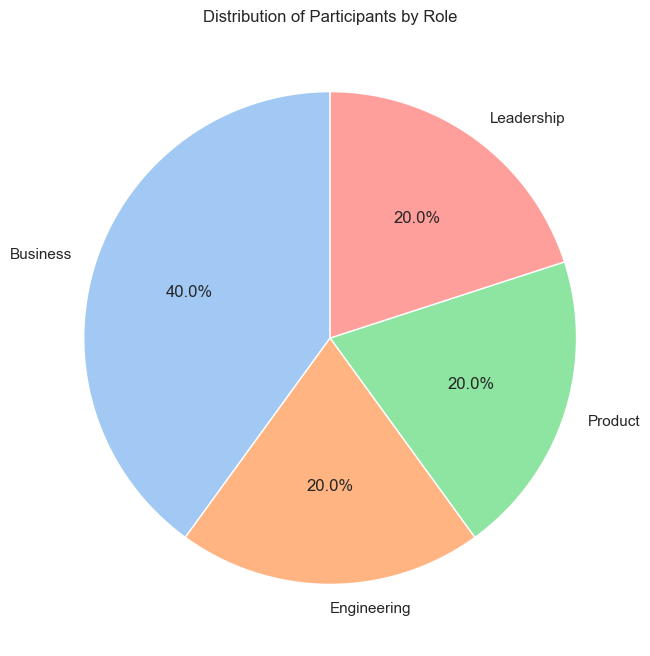

In [27]:
# Create a pie chart for participant roles
plt.figure(figsize=(8, 8))
participants_per_role.plot.pie(autopct='%1.1f%%', startangle=90, labels=participants_per_role.index, colors=sns.color_palette("pastel"))
plt.title("Distribution of Participants by Role")
plt.ylabel("")  # Remove the y-axis label
plt.show()

# Quantitative Analysis

## 🔹 Domains

### Average score per Domain

In [28]:
# Initialize a dictionary to store the average scores for each domain
domain_scores = {}

# Extract unique domains from the 'Category' column of the questionnaire
domains = questionnaire['Category'].unique()

# Iterate through each domain
for domain in domains:
    # Get the IDs of questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    
    # Filter the domain_question_ids to include only those present in combined_quantitative_df
    valid_domain_question_ids = [qid for qid in domain_question_ids if qid in combined_quantitative_df.columns]
    
    # Filter the combined_quantitative_df for the current domain's questions
    domain_data = combined_quantitative_df[valid_domain_question_ids]
    # Calculate the average score for answered questions (non-zero values)
    domain_average = domain_data[domain_data > 0].mean(axis=1).mean()
    
    # Round the average to 1 decimal point and store it in the dictionary
    domain_scores[domain] = round(domain_average, 1)

# Print the domain scores
for domain in domain_scores:
    # Check if the domain score is greater than 0
    if domain_scores[domain] > 0:
        # Print the domain and its average score
        print(f"{domain}: {domain_scores[domain]}")
    else:
        # Print a message indicating no valid scores for the domain
        print(f"{domain}: No valid scores")

Architecture & Technology: 3.6
Team Capability: 3.7
Governance & Delivery: 3.6
Integration & Data Readiness: 2.9
Business Alignment & Strategy: 3.4
Cultural Readiness: 3.6


### Role-Based Sentiment Scores with Variance and Range

In [29]:
# Initialize a dictionary to store role-based sentiment scores
role_sentiments = {response['role']: {} for response in responses}

# Iterate through each role
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index
    
    # Group questions by domain
    for domain, domain_questions in questionnaire.loc[role_question_ids].groupby('Category'):
        # Filter the quantitative data for the current domain and role
        valid_columns = [col for col in domain_questions.index if col in combined_quantitative_df.columns]
        domain_data = combined_quantitative_df[valid_columns]
        
        # Calculate the average score for answered questions (non-zero values)
        domain_average = domain_data[domain_data > 0].mean(axis=1).mean()
        
        # Store the rounded average in the role_sentiments dictionary
        role_sentiments[role][domain] = round(domain_average, 1)

# Highlight domains with lower confidence
low_confidence_roles = {}

for role, domains in role_sentiments.items():
    for domain, score in domains.items():
        if score < threshold_confidence_low:
            if domain not in low_confidence_roles:
                low_confidence_roles[domain] = []
            low_confidence_roles[domain].append((role, score))

# Convert role_sentiments to a DataFrame for easier manipulation
role_sentiments_df = pd.DataFrame(role_sentiments)

variance = role_sentiments_df.var(axis=1, skipna=True)
range = role_sentiments_df.apply(lambda row: row.max(skipna=True) - row.min(skipna=True), axis=1)

# Add variance and range to the DataFrame
role_sentiments_df['Variance'] = variance
role_sentiments_df['Range'] = range

# Print the table with scores, variance, and range
print("\nRole-Based Sentiment Scores with Variance and Range:")
print(role_sentiments_df)

print("\n\n ------------------------------- \n\n")

# Print domains with low confidence
print("\nDomains with particularly low Confidence:")
for domain, roles in low_confidence_roles.items():
    print(f"{domain}:")
    for role, score in roles:
        print(f"  {role}: {score}")



Role-Based Sentiment Scores with Variance and Range:
                               Engineering  Product  Business  Leadership  \
Architecture & Technology              3.6      3.2       NaN         3.0   
Business Alignment & Strategy          3.0      4.1       3.1         3.2   
Cultural Readiness                     3.6      3.6       3.6         3.6   
Governance & Delivery                  3.2      3.8       4.0         3.4   
Integration & Data Readiness           2.8      1.8       3.9         3.5   
Team Capability                        3.7      3.8       NaN         4.3   

                               Variance  Range  
Architecture & Technology      0.093333    0.6  
Business Alignment & Strategy  0.256667    1.1  
Cultural Readiness             0.000000    0.0  
Governance & Delivery          0.133333    0.8  
Integration & Data Readiness   0.846667    2.1  
Team Capability                0.103333    0.6  


 ------------------------------- 



Domains with particularl

### Heatmap

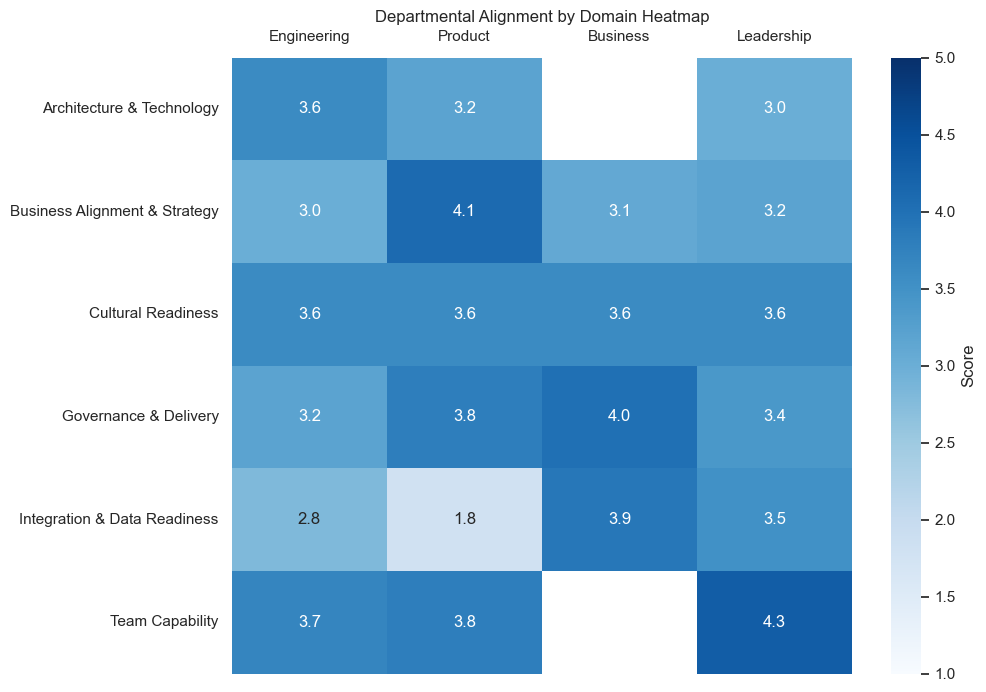

In [30]:
# Convert role_sentiments to a DataFrame for easier plotting
# Set the style for the heatmap
sns.set(style="white")

# Convert role_sentiments to a DataFrame for easier plotting
role_sentiments_df = pd.DataFrame(role_sentiments)

# Create the heatmap
plt.figure(figsize=(10, 8))

# Set axis labels and title
plt.title("Departmental Alignment by Domain Heatmap")
plt.tick_params(top=False, labeltop=True, bottom=False, labelbottom=False)
# plt.xlabel("Role")
# plt.ylabel("Theme")

# Create the heatmap with annotations
sns.heatmap(role_sentiments_df, annot=True, cmap="Blues", vmin=1, vmax=5, cbar_kws={'label': 'Score'}, fmt=".1f")

# Show the plot
plt.show()

### Domain based Critical Question Weighting

You can optionally flag critical questions in the report. They aren’t weighted more heavily in the score but:
If average of critical questions < 3, flag domain as "At Risk"
If < 2.5, flag as "Critical Risk"

In [31]:
# Initialize a dictionary to store the risk flags for each domain
domain_risk_flags = {}

# Iterate through each domain
for domain in domains:
    # Get the IDs of questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    
    # Filter for critical questions within the domain
    critical_question_ids = domain_question_ids[questionnaire.loc[domain_question_ids, 'Critical']]
    
    # Filter the combined_quantitative_df for the critical questions in the current domain
    critical_data = combined_quantitative_df[critical_question_ids]
    
    # Calculate the average score for answered critical questions (non-zero values)
    critical_average = critical_data[critical_data > 0].mean(axis=1).mean()
    
    # Determine the risk flag based on the average score
    if critical_average < threshold_risk_critical:
        domain_risk_flags[domain] = "Critical Risk"
    elif critical_average < threshold_risk_average:
        domain_risk_flags[domain] = "At Risk"
    else:
        domain_risk_flags[domain] = "No Risk"

# Print the risk flags for each domain
for domain in domain_risk_flags:
    # Print the domain and its risk flag
    print(f"{domain}: {domain_risk_flags[domain]}")

Architecture & Technology: No Risk
Business Alignment & Strategy: No Risk
Cultural Readiness: No Risk
Governance & Delivery: No Risk
Integration & Data Readiness: No Risk
Team Capability: No Risk


### Overall Domain Readiness Score

Calculate a simple mean of all domain scores (equal weights).
Apply RAG logic to overall score for summary visualisation.

| Score Range | Status | Colour | Interpretation |
| ----------- | ------ | ------ | -------------- |
| 4.0 – 5.0 | Ready | 🟢 Green | High maturity and alignment |
| 3.0 – 3.9 | Caution | 🟡 Amber | Some concerns, manageable risk |
| < 3.0 | Not Ready | 🔴 Red | Significant blockers or misalignment |


In [32]:
# Initialize dictionaries to store clustering results
amber_clusters = {}
red_clusters = {}

# Iterate through roles and their domain scores
for role, domains in role_sentiments.items():
    for domain, score in domains.items():
        if score < rag_score_low:
            if domain not in red_clusters:
                red_clusters[domain] = []
            red_clusters[domain].append((role, score))
        elif score < rag_score_average:
            if domain not in amber_clusters:
                amber_clusters[domain] = []
            amber_clusters[domain].append((role, score))

# Print clustering results
print(f"🔴 Red Clusters (Scores < {rag_score_low}):")
for domain, roles in red_clusters.items():
    print(f"{domain}:")
    for role, score in roles:
        print(f"  {role}: {score}")

print("\n\n ------------------------------- \n\n")

print(f"🟡 Amber Clusters (Scores < {rag_score_average}):")
for domain, roles in amber_clusters.items():
    print(f"{domain}:")
    for role, score in roles:
        print(f"  {role}: {score}")

🔴 Red Clusters (Scores < 3):
Integration & Data Readiness:
  Engineering: 2.8
  Product: 1.8


 ------------------------------- 


🟡 Amber Clusters (Scores < 3.9):
Architecture & Technology:
  Engineering: 3.6
  Product: 3.2
  Leadership: 3.0
Business Alignment & Strategy:
  Engineering: 3.0
  Business: 3.1
  Leadership: 3.2
Cultural Readiness:
  Engineering: 3.6
  Product: 3.6
  Business: 3.6
  Leadership: 3.6
Governance & Delivery:
  Engineering: 3.2
  Product: 3.8
  Leadership: 3.4
Team Capability:
  Engineering: 3.7
  Product: 3.8
Integration & Data Readiness:
  Leadership: 3.5


## 🔹 Themes

### Average scores per Theme

In [33]:
# Initialize a dictionary to store theme-based scores
theme_scores = {}

# Filter out rows with NaN themes
themed_questions = questionnaire.dropna(subset=['Theme'])

# Group questions by theme
for theme, theme_questions in themed_questions.groupby('Theme'):
    # Get the IDs of questions belonging to the current theme
    theme_question_ids = theme_questions.index
    
    # Filter the combined quantitative data for the current theme's questions
    valid_theme_question_ids = [qid for qid in theme_question_ids if qid in combined_quantitative_df.columns]
    theme_data = combined_quantitative_df[valid_theme_question_ids]
    
    # Calculate the average score for answered questions (non-zero values)
    theme_average = theme_data[theme_data > 0].mean(axis=1).mean()
    
    # Store the rounded average in the theme_scores dictionary
    theme_scores[theme] = round(theme_average, 1)

# Print the theme-based scores
print("Theme-Based Scores:")
for theme, score in theme_scores.items():
    print(f"{theme}: {score}")

# highlight themes with low confidence
low_confidence_themes = {}
for theme, score in theme_scores.items():
    if score < threshold_confidence_low:
        low_confidence_themes[theme] = score

print("\n\n ------------------------------- \n\n")

# Print themes with low confidence
print("\nThemes with particularly low Confidence:")
for theme, score in low_confidence_themes.items():
    print(f"{theme}: {score}")

Theme-Based Scores:
Autonomy & Empowerment: 2.6
Clear Ownership: 3.5
Composable Integration: 2.4
Cross-Functional Alignment: 3.8
Data Trust & Stewardship: 3.3
Delivery Friction: 3.7
Legacy Constraints: 2.2
Platform vs. Feature Tension: 3.4
Readiness for Change: 3.8
Strategic Sponsorship: 2.2
Technical Confidence: 3.0
Testing & Quality: 3.0


 ------------------------------- 



Themes with particularly low Confidence:
Autonomy & Empowerment: 2.6
Composable Integration: 2.4
Legacy Constraints: 2.2
Strategic Sponsorship: 2.2


### Theme-Based Sentiment Scores with Variance and Range

In [34]:
# Initialize a dictionary to store theme scores by role
theme_scores_by_role = {}

# Iterate through each role
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index
    
    # Filter the themed questions for the current role
    role_themed_questions = themed_questions[themed_questions.index.isin(role_question_ids)]
    
    # Calculate theme scores for the current role
    theme_scores_by_role[role] = {
        theme: combined_quantitative_df.loc[:, group.index].replace(0, np.nan).mean(axis=1).mean().round(1)
        for theme, group in role_themed_questions.groupby('Theme')
    }

# Convert theme_scores_by_role to a DataFrame for variance and range calculation
theme_scores_df = pd.DataFrame(theme_scores_by_role)

# Add a column for variance across roles for each theme
# and calculate the variance and range
variance = theme_scores_df.var(axis=1, skipna=True)
range = theme_scores_df.apply(lambda row: row.max(skipna=True) - row.min(skipna=True), axis=1)
theme_scores_df['Variance'] = variance
theme_scores_df['Range'] = range

# Print the table with values, variance, and range
print("\nTheme Scores by Role with Variance and Range:")
print(theme_scores_df)



Theme Scores by Role with Variance and Range:
                              Engineering  Product  Business  Leadership  \
Autonomy & Empowerment                2.6      3.5       NaN         3.0   
Clear Ownership                       3.8      3.3       3.3         3.0   
Composable Integration                2.4      2.5       NaN         NaN   
Cross-Functional Alignment            3.9      4.0       4.0         3.8   
Data Trust & Stewardship              3.3      NaN       4.0         3.0   
Delivery Friction                     3.4      3.6       NaN         3.5   
Legacy Constraints                    2.2      2.0       2.0         2.0   
Platform vs. Feature Tension          3.9      4.2       NaN         3.8   
Readiness for Change                  3.8      3.9       4.6         3.7   
Technical Confidence                  3.0      NaN       NaN         NaN   
Testing & Quality                     3.0      NaN       NaN         NaN   
Strategic Sponsorship                 NaN

### Heatmap

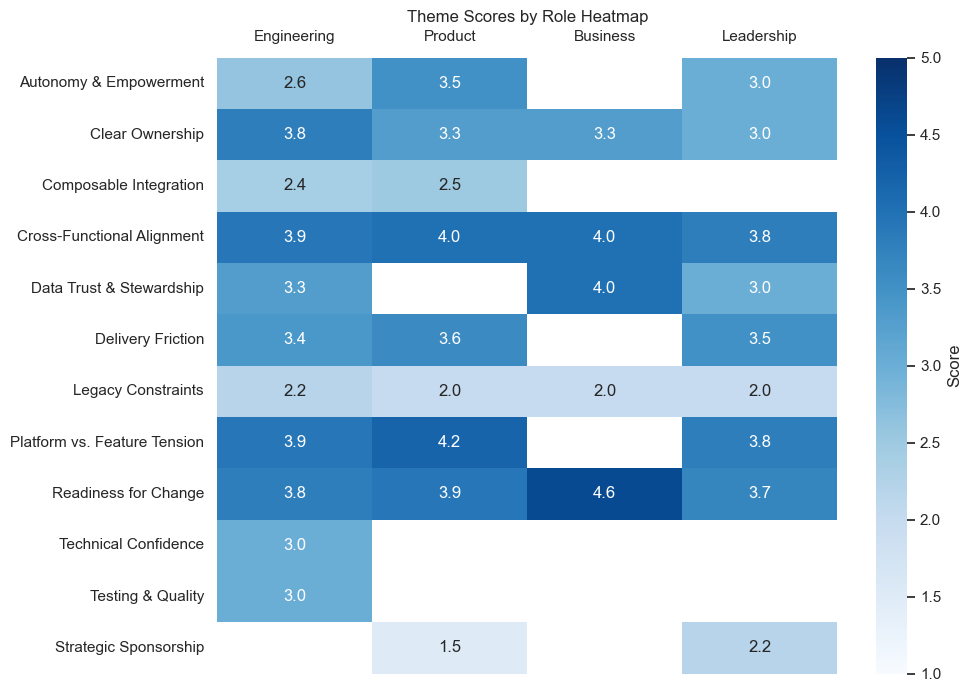

In [35]:
# Set the style for the heatmap
sns.set(style="white")
# Convert theme_scores_by_role to a DataFrame for easier plotting
theme_scores_df = pd.DataFrame(theme_scores_by_role)

# Create the heatmap
plt.figure(figsize=(10, 8))

# Set axis labels and title
plt.title("Theme Scores by Role Heatmap")
plt.tick_params(top=False, labeltop=True, bottom=False, labelbottom=False)
# plt.xlabel("Role")
# plt.ylabel("Theme")

# Create the heatmap with annotations
sns.heatmap(theme_scores_df, annot=True, cmap="Blues", vmin=1, vmax=5, cbar_kws={'label': 'Score'}, fmt=".1f")

# Show the plot
plt.show()


### Role-Based variance for each Theme

<Figure size 1200x800 with 0 Axes>

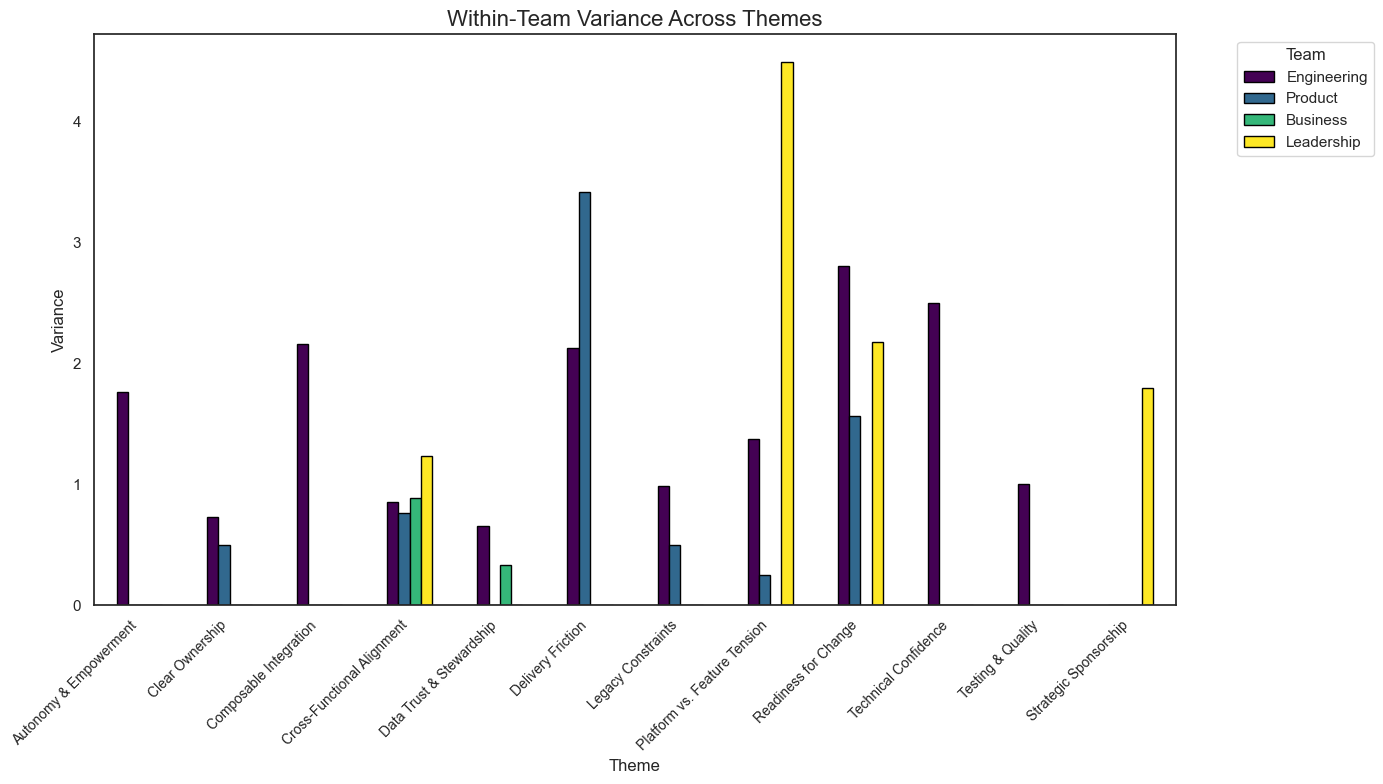

In [36]:
# Calculate within-team variance for each theme
theme_variance_by_team = {}

# Iterate through each role (team)
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index

    # Filter the themed questions for the current role
    role_themed_questions = themed_questions[themed_questions.index.isin(role_question_ids)]

    # Calculate variance for each theme within the current role
    theme_variance_by_team[role] = {
        theme: combined_quantitative_df.loc[:, group.index].replace(0, np.nan).var(axis=1, skipna=True).mean()
        for theme, group in role_themed_questions.groupby('Theme')
    }

# Convert the variance data to a DataFrame for easier plotting
theme_variance_df = pd.DataFrame(theme_variance_by_team)

# Plot the within-team variance across themes
plt.figure(figsize=(12, 8))
theme_variance_df.plot(kind='bar', figsize=(14, 8), edgecolor='black', colormap='viridis')

# Set plot labels and title
plt.title("Within-Team Variance Across Themes", fontsize=16)
plt.xlabel("Theme", fontsize=12)
plt.ylabel("Variance", fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.legend(title="Team", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

### Roles with most variance in perception

In [37]:
# Calculate variance for each role across all domains
role_variances = {role: np.nanvar(list(domains.values())) for role, domains in role_sentiments.items()}

# Find the role with the highest variance
max_variance_role = max(role_variances, key=role_variances.get)
max_variance_value = role_variances[max_variance_role]

# Print the results
for role_variane in role_variances.items():
    print(f"{role_variane[0]}: {role_variane[1]:.2f}")

print(f"Role with the most variance: {max_variance_role} (Variance: {max_variance_value:.2f})")

Engineering: 0.11
Product: 0.57
Business: 0.12
Leadership: 0.17
Role with the most variance: Product (Variance: 0.57)


### Theme based Critical Question Weighting

You can optionally flag critical questions in the report. They aren’t weighted more heavily in the score but:
If average of critical questions < 3, flag theme as "At Risk"
If < 2.5, flag as "Critical Risk"

In [38]:
# Initialize a dictionary to store the risk flags for each theme
theme_risk_flags = {}

# Iterate through each theme
for theme, theme_questions in themed_questions.groupby('Theme'):
    # Get the IDs of critical questions belonging to the current theme
    critical_question_ids = theme_questions[theme_questions['Critical']].index
    
    # Filter the combined quantitative data for the critical questions in the current theme
    critical_data = combined_quantitative_df[critical_question_ids]
    
    # Calculate the average score for answered critical questions (non-zero values)
    critical_average = critical_data[critical_data > 0].mean(axis=1).mean()
    
    # Determine the risk flag based on the average score
    if critical_average < threshold_risk_critical:
        theme_risk_flags[theme] = "Critical Risk"
    elif critical_average < threshold_risk_average:
        theme_risk_flags[theme] = "At Risk"
    else:
        theme_risk_flags[theme] = "No Risk"

# Print the risk flags for each theme
for theme, risk_flag in theme_risk_flags.items():
    print(f"{theme}: {risk_flag}")

Autonomy & Empowerment: No Risk
Clear Ownership: No Risk
Composable Integration: At Risk
Cross-Functional Alignment: No Risk
Data Trust & Stewardship: No Risk
Delivery Friction: No Risk
Legacy Constraints: Critical Risk
Platform vs. Feature Tension: Critical Risk
Readiness for Change: No Risk
Strategic Sponsorship: No Risk
Technical Confidence: No Risk
Testing & Quality: No Risk


### Overall Theme Readiness Score

Calculate a simple mean of all domain scores (equal weights).
Apply RAG logic to overall score for summary visualisation.

| Score Range | Status | Colour | Interpretation |
| ----------- | ------ | ------ | -------------- |
| 4.0 – 5.0 | Ready | 🟢 Green | High maturity and alignment |
| 3.0 – 3.9 | Caution | 🟡 Amber | Some concerns, manageable risk |
| < 3.0 | Not Ready | 🔴 Red | Significant blockers or misalignment |


In [39]:
# Initialize dictionaries to store clustering results for themes
amber_theme_clusters = {}
red_theme_clusters = {}

# Iterate through roles and their theme scores
for role, themes in theme_scores_by_role.items():
    for theme, score in themes.items():
        if score < rag_score_low:
            if theme not in red_theme_clusters:
                red_theme_clusters[theme] = []
            red_theme_clusters[theme].append((role, score))
        elif score < rag_score_average:
            if theme not in amber_theme_clusters:
                amber_theme_clusters[theme] = []
            amber_theme_clusters[theme].append((role, score))

# Print clustering results for themes
print(f"🔴 Red Theme Clusters (Scores < {rag_score_low}):")
for theme, roles in red_theme_clusters.items():
    print(f"{theme}:")
    for role, score in roles:
        print(f"  {role}: {score}")

print("\n\n ------------------------------- \n\n")

print(f"🟡 Amber Theme Clusters (Scores < {rag_score_average}):")
for theme, roles in amber_theme_clusters.items():
    print(f"{theme}:")
    for role, score in roles:
        print(f"  {role}: {score}")

🔴 Red Theme Clusters (Scores < 3):
Autonomy & Empowerment:
  Engineering: 2.6
Composable Integration:
  Engineering: 2.4
  Product: 2.5
Legacy Constraints:
  Engineering: 2.2
  Product: 2.0
  Business: 2.0
  Leadership: 2.0
Strategic Sponsorship:
  Product: 1.5
  Leadership: 2.2


 ------------------------------- 


🟡 Amber Theme Clusters (Scores < 3.9):
Clear Ownership:
  Engineering: 3.8
  Product: 3.3
  Business: 3.3
  Leadership: 3.0
Data Trust & Stewardship:
  Engineering: 3.3
  Leadership: 3.0
Delivery Friction:
  Engineering: 3.4
  Product: 3.6
  Leadership: 3.5
Readiness for Change:
  Engineering: 3.8
  Leadership: 3.7
Technical Confidence:
  Engineering: 3.0
Testing & Quality:
  Engineering: 3.0
Autonomy & Empowerment:
  Product: 3.5
  Leadership: 3.0
Cross-Functional Alignment:
  Leadership: 3.8
Platform vs. Feature Tension:
  Leadership: 3.8


## 🔹 Overall rating

### Overall readiness for the migration

| Score Range | Status | Colour | Interpretation |
| ----------- | ------ | ------ | -------------- |
| 4.0 – 5.0 | Ready | 🟢 Green | High maturity and alignment |
| 3.0 – 3.9 | Caution | 🟡 Amber | Some concerns, manageable risk |
| < 3.0 | Not Ready | 🔴 Red | Significant blockers or misalignment |

In [40]:
# Calculate the mean of all domain scores
overall_score = round(np.nanmean([score for domain_scores in role_sentiments.values() for score in domain_scores.values()]), 1)

# Apply RAG logic
if overall_score < rag_score_low:
    rag_status = "🔴 Red"
elif overall_score <= rag_score_average:
    rag_status = "🟡 Amber"
else:
    rag_status = "🟢 Green"

# Print the overall score and RAG status
print(f"Overall Score: {overall_score}")
print(f"RAG Status: {rag_status}")

Overall Score: 3.4
RAG Status: 🟡 Amber


### Questions and the distribution of their Responses by Domain

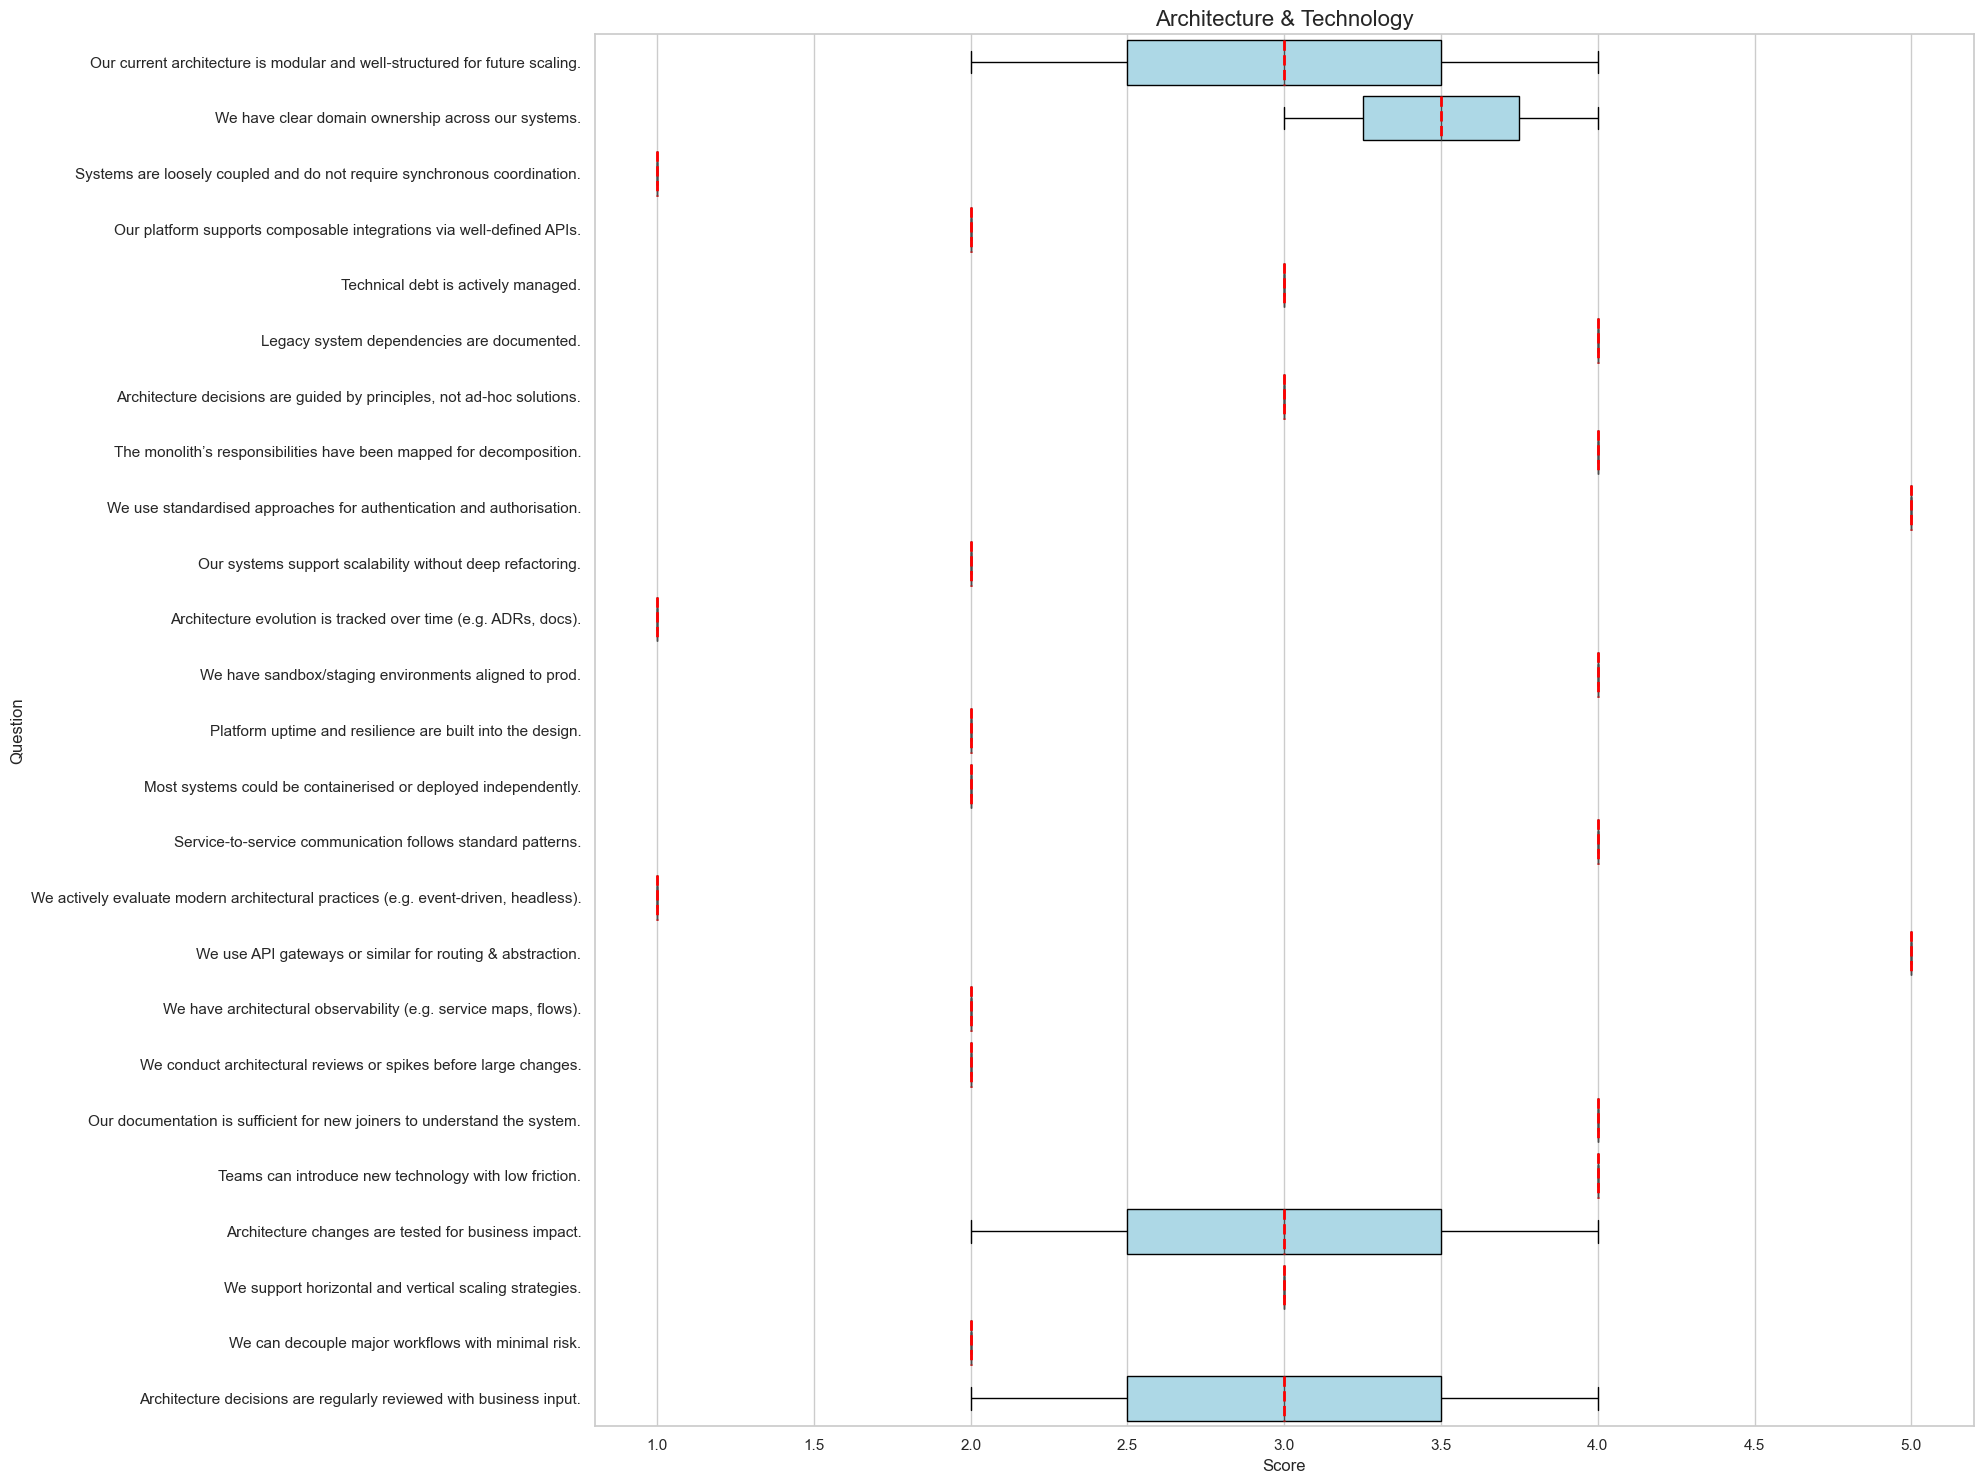

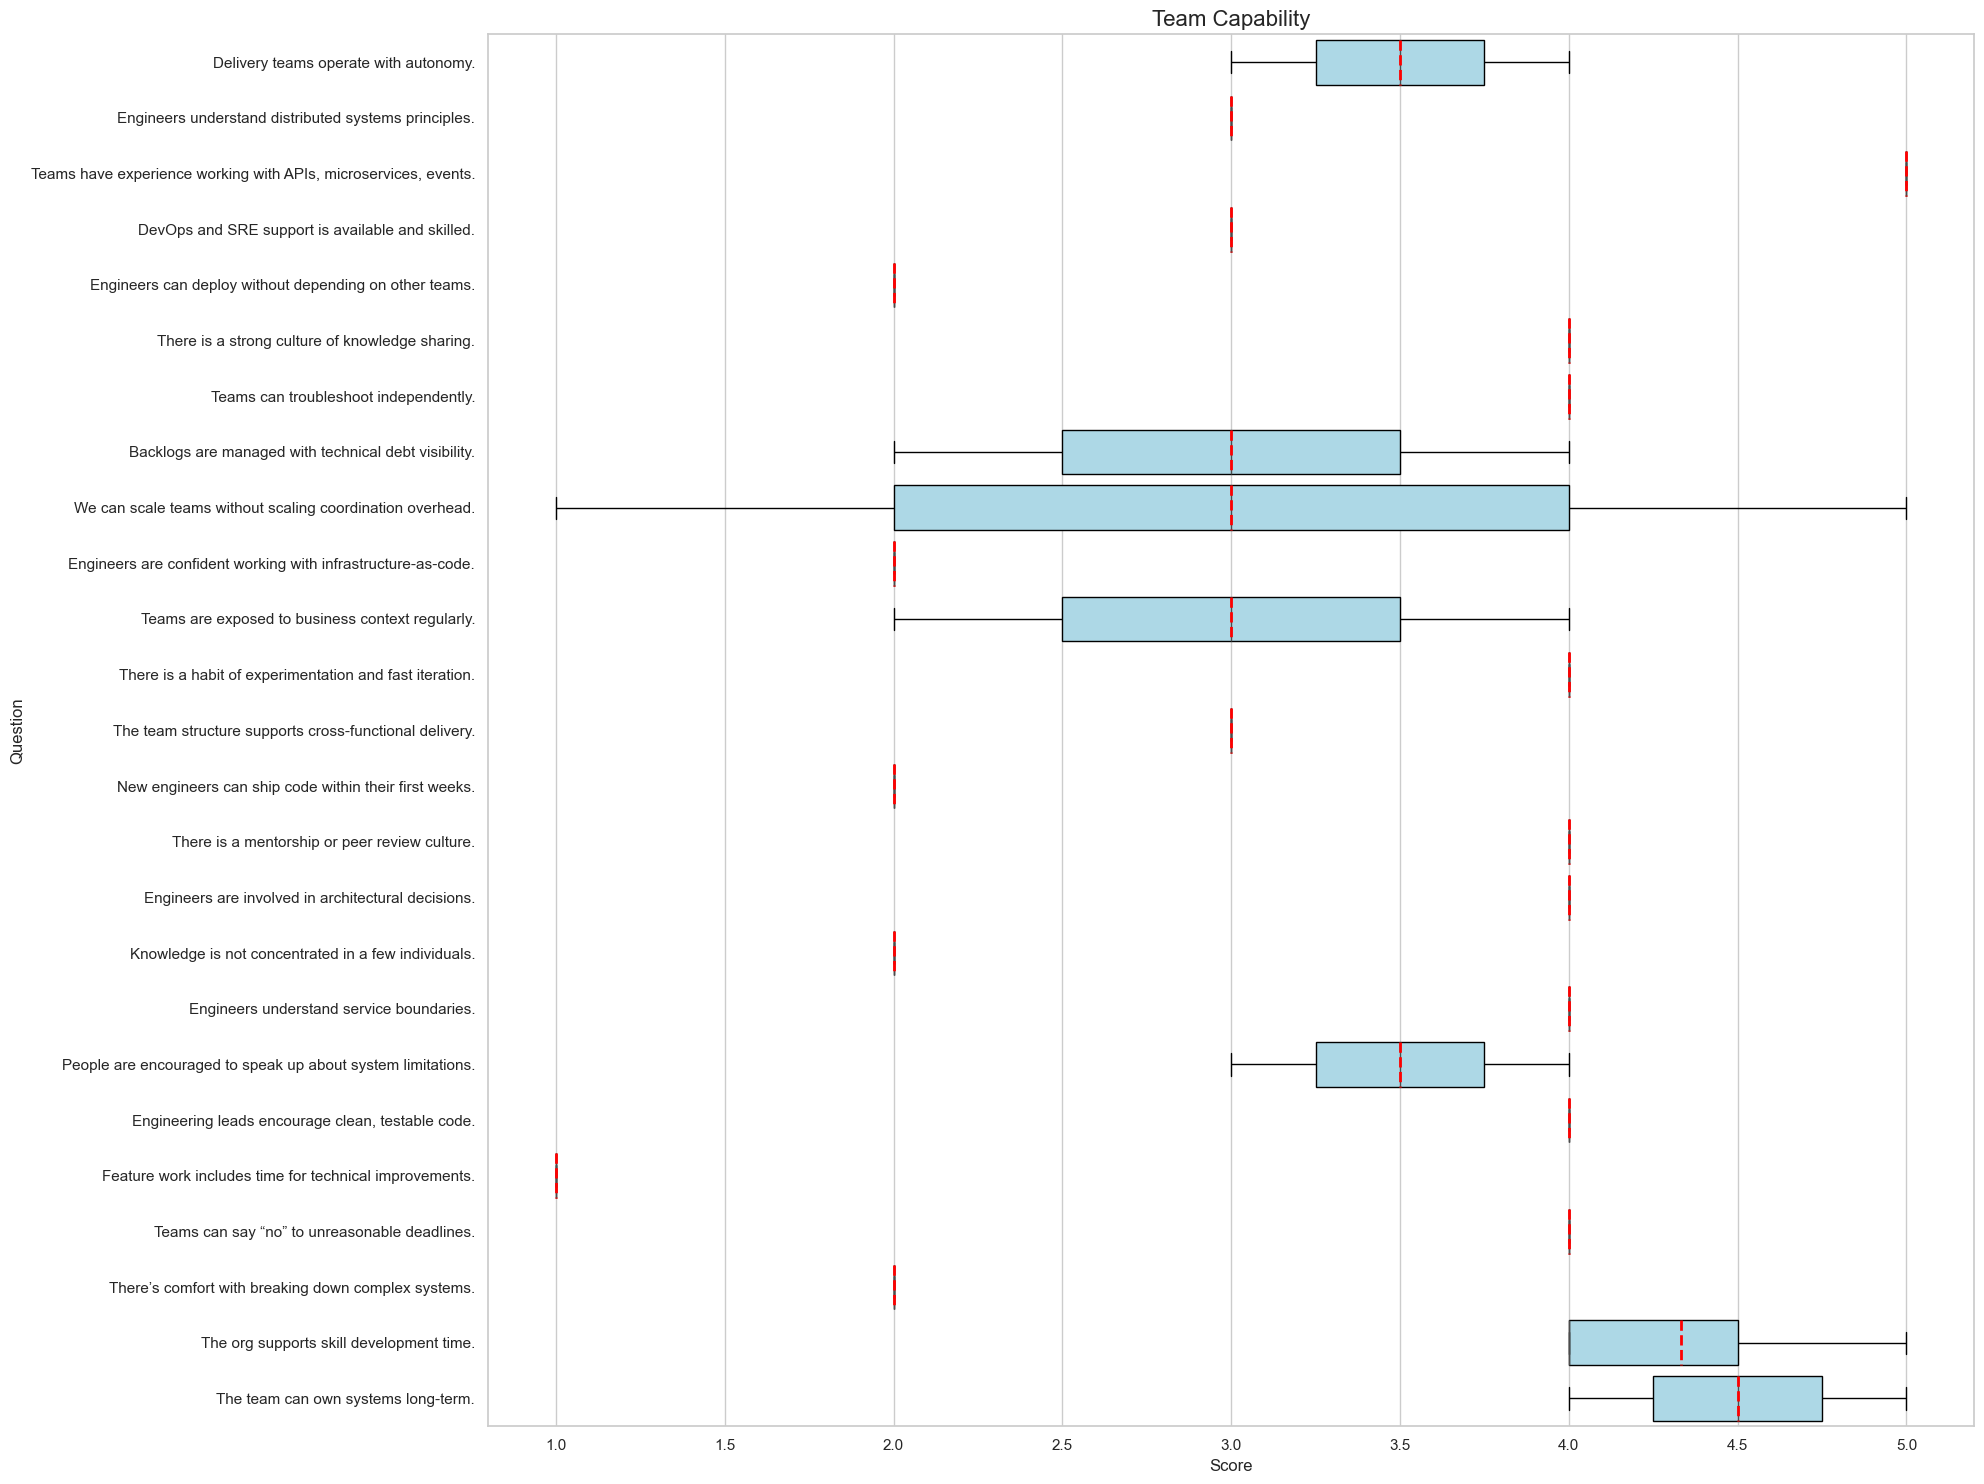

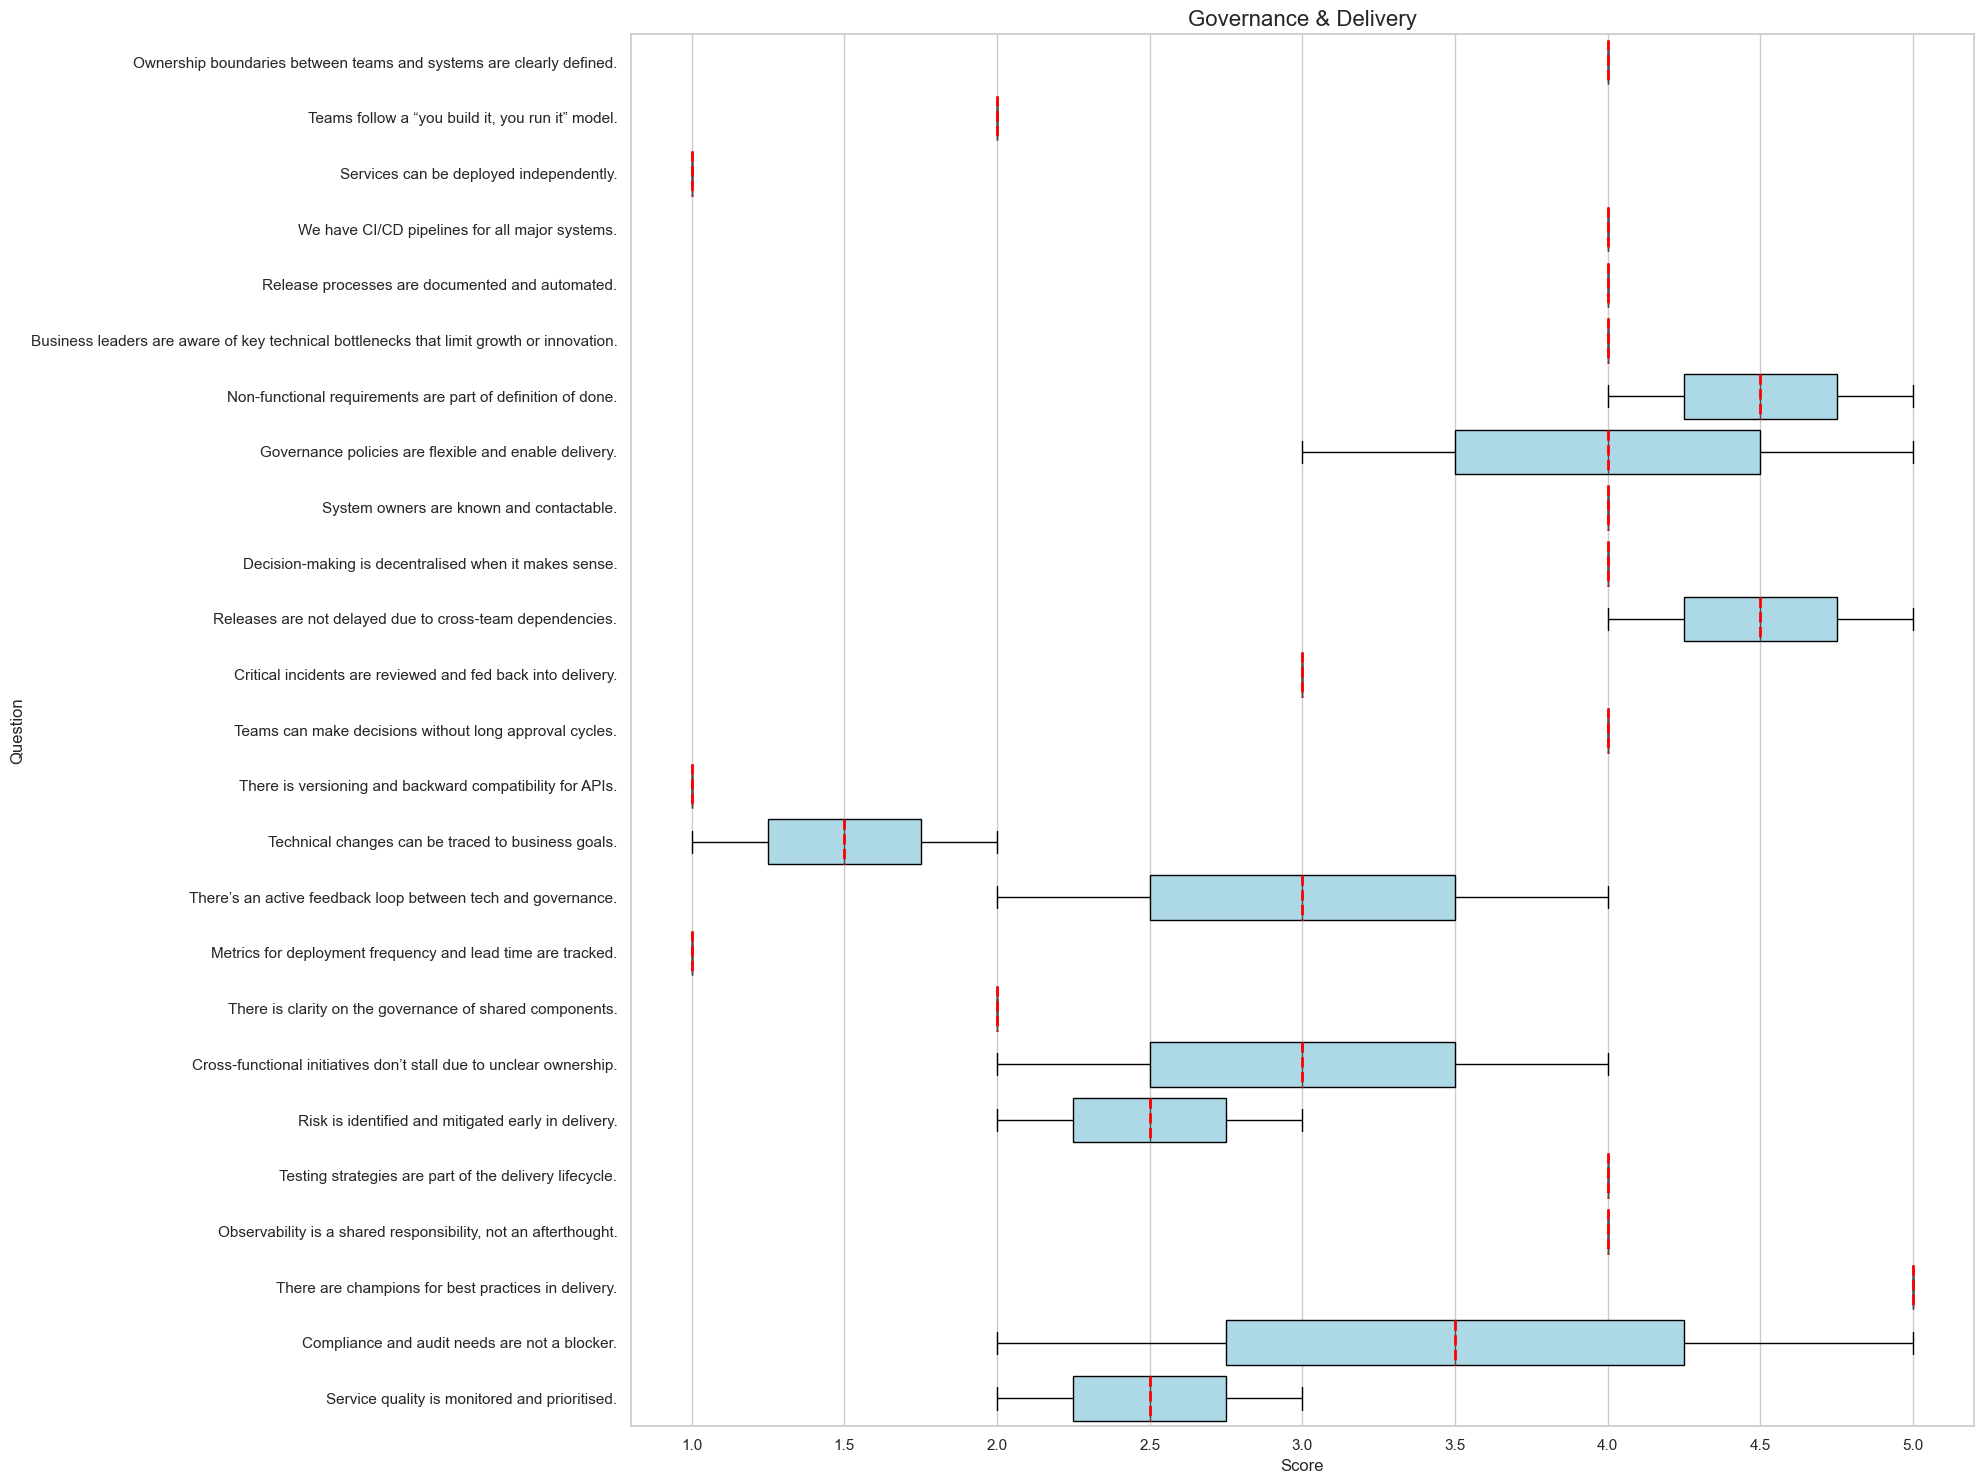

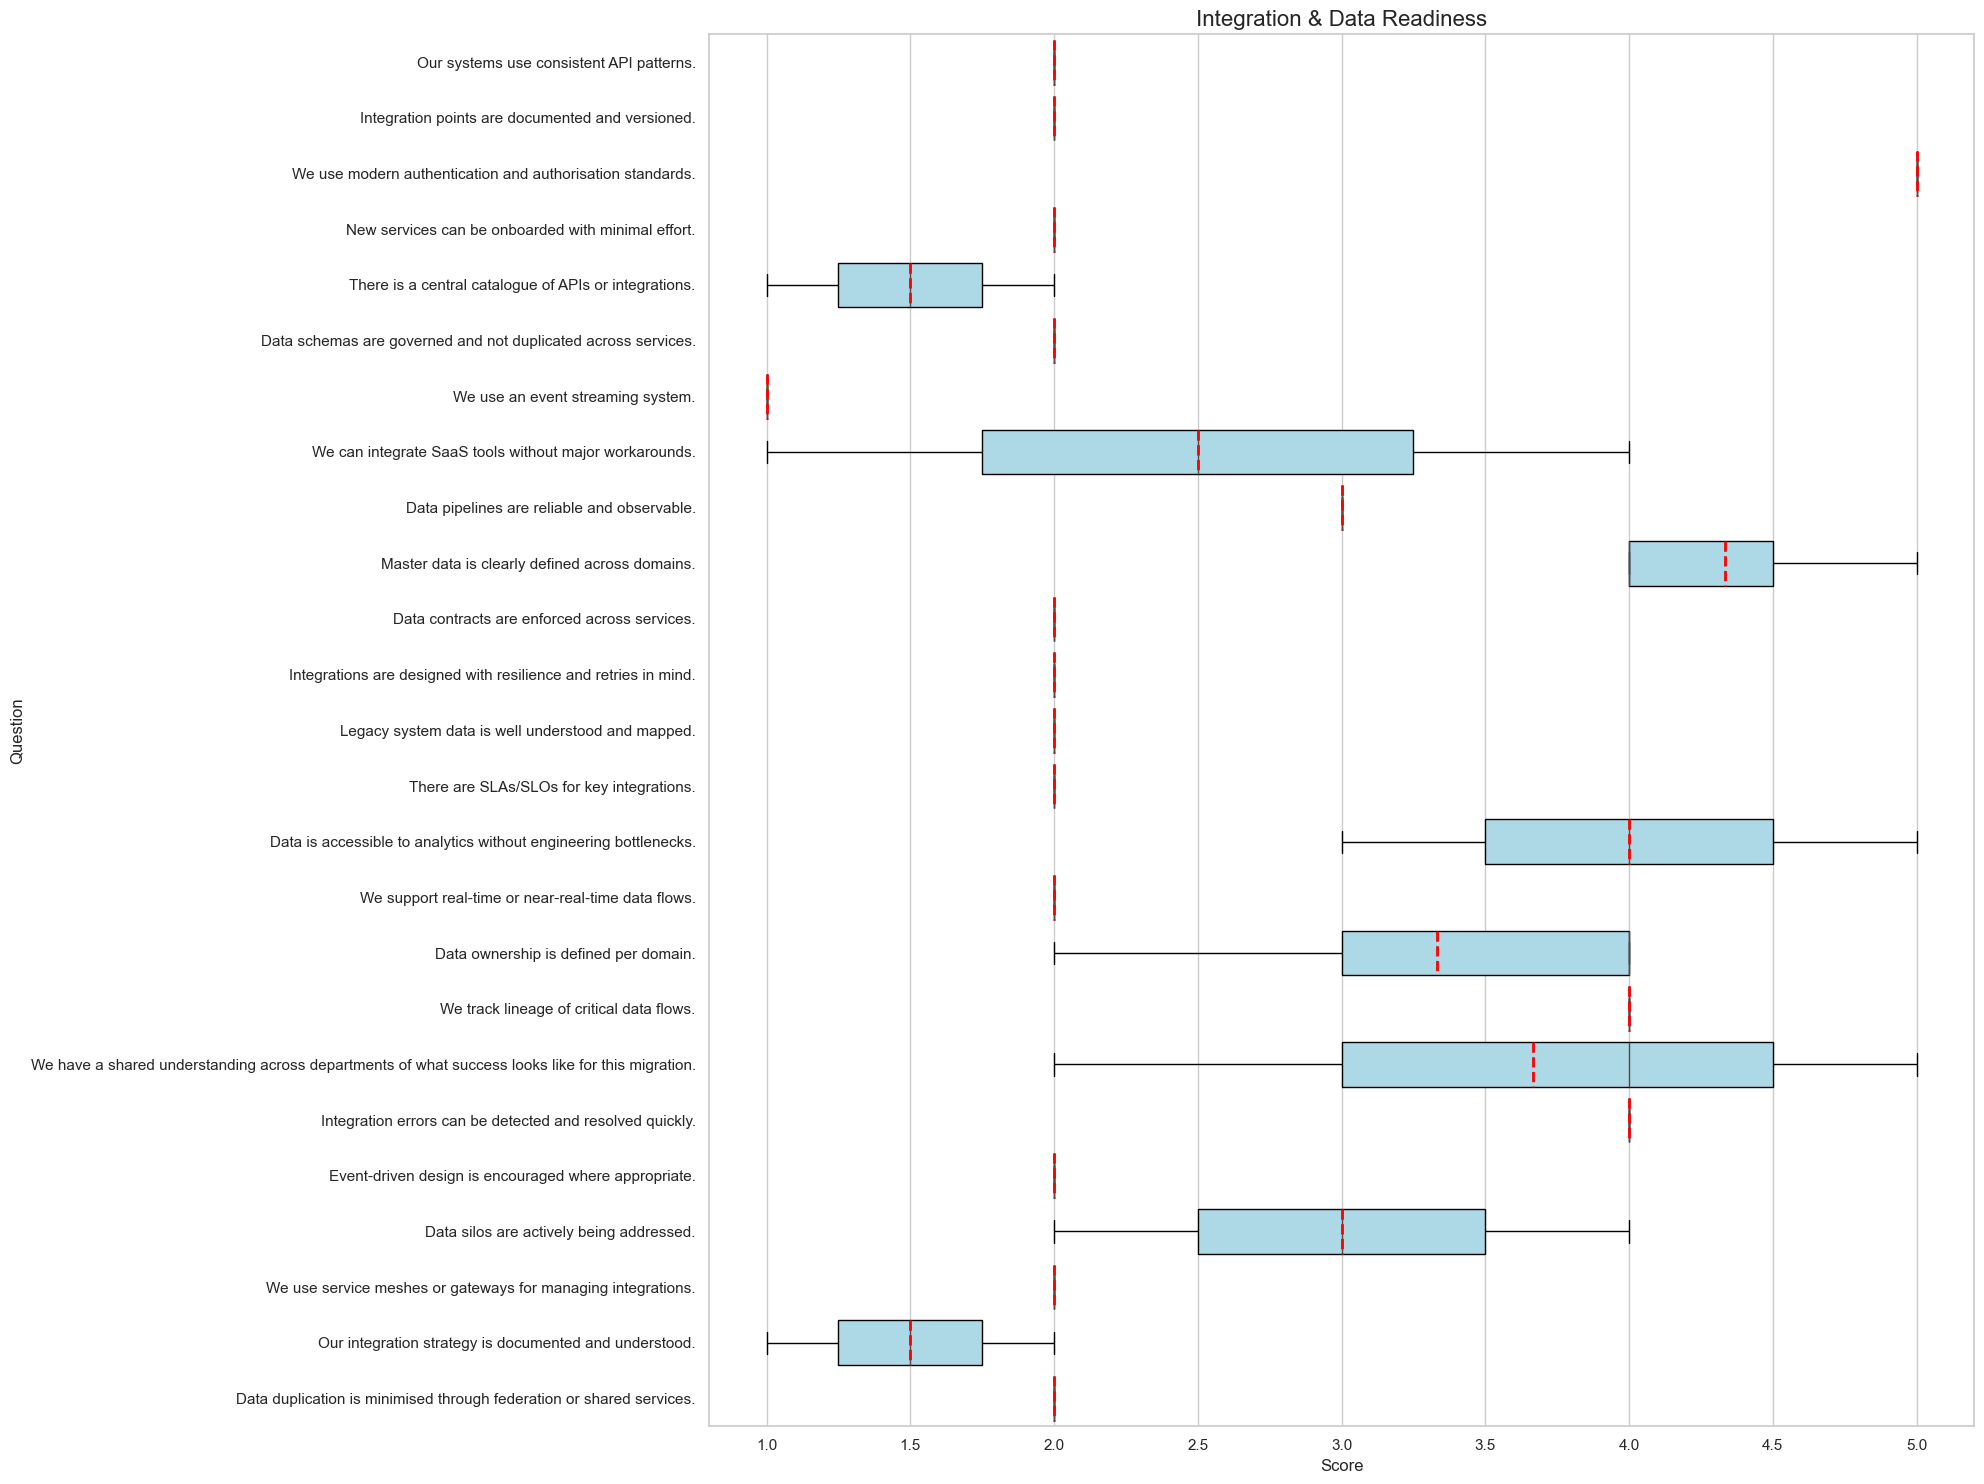

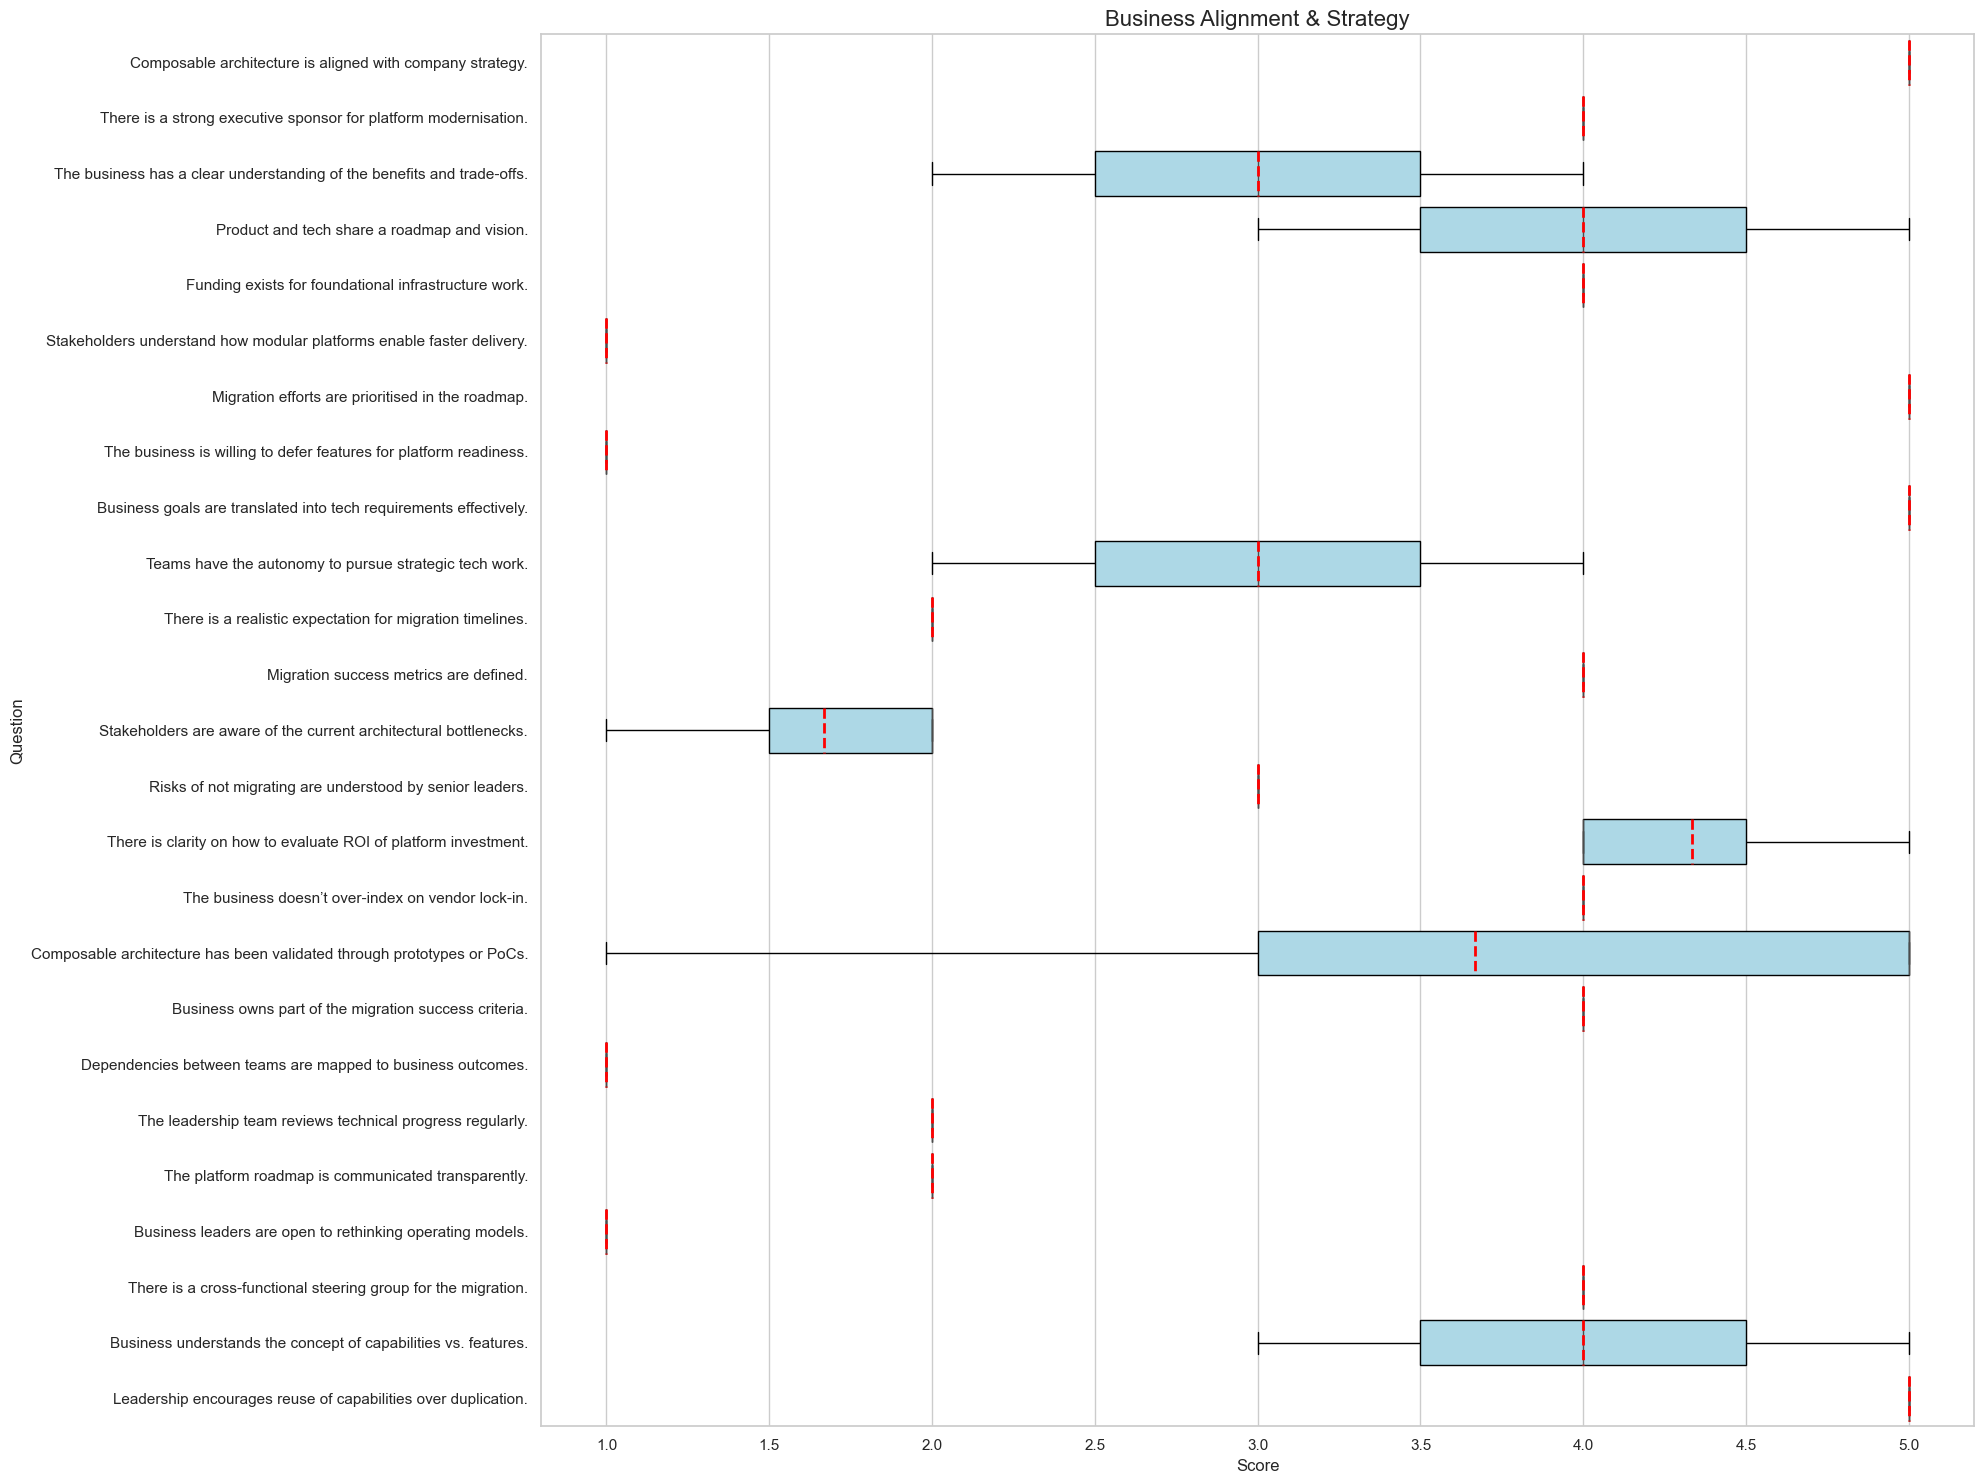

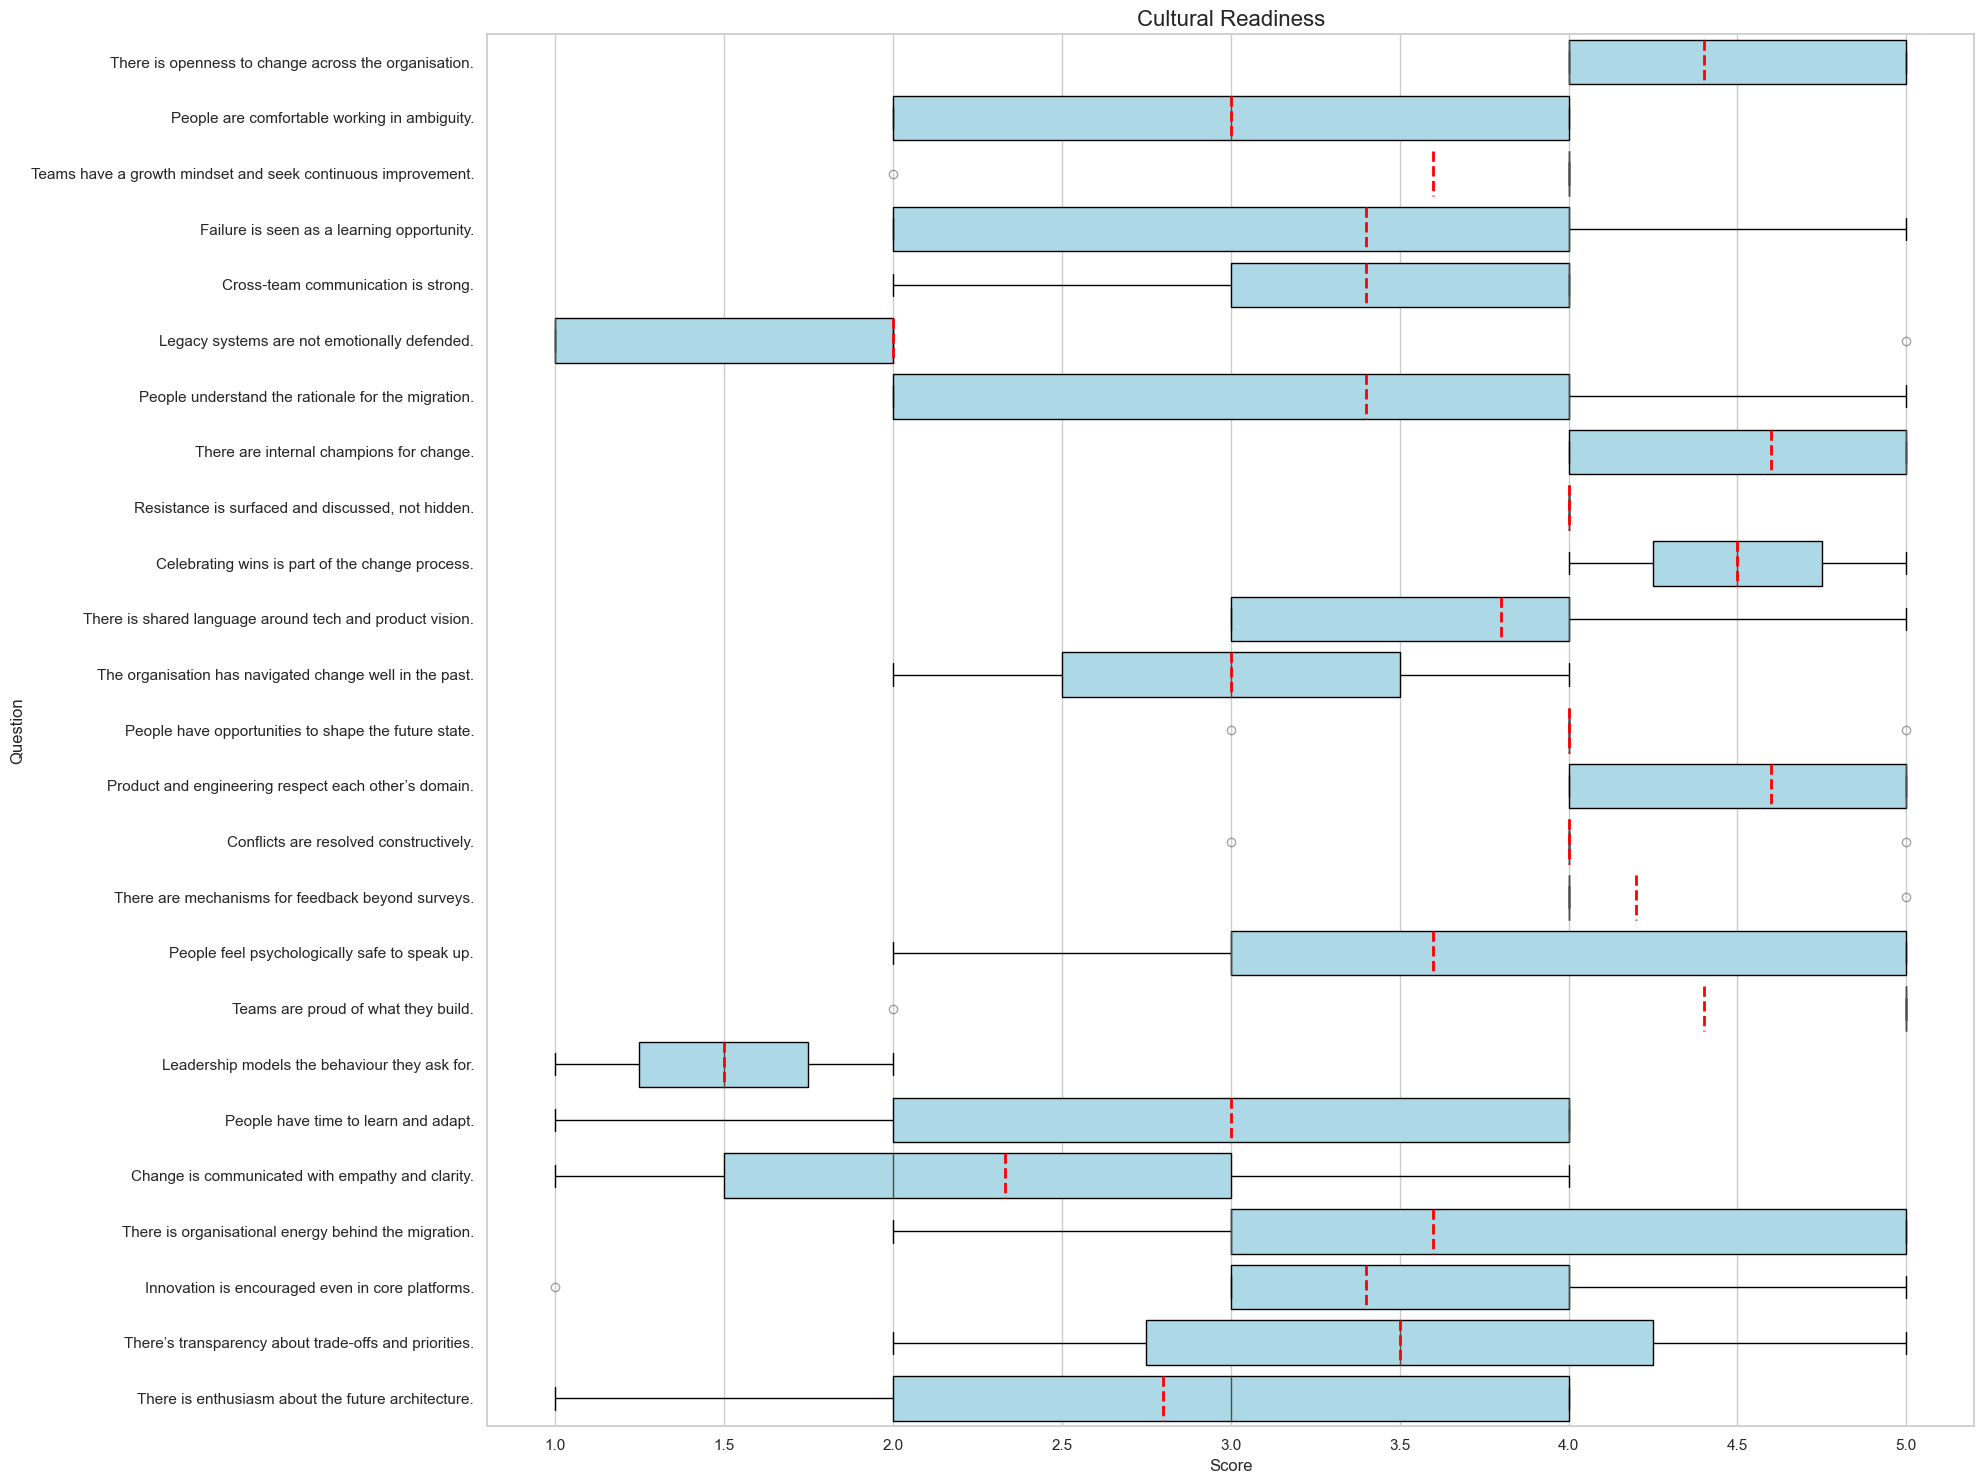

In [41]:
# Set the style for the plots
sns.set(style="whitegrid")

# Group questions by their domain
domains = questionnaire['Category'].unique()

# Iterate through each domain
for domain in domains:
    # Filter questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    valid_domain_question_ids = [qid for qid in domain_question_ids if qid in combined_quantitative_df.columns]
    
    # Filter the quantitative data for the current domain's questions
    domain_data = combined_quantitative_df[valid_domain_question_ids].replace(0, np.nan)
    
    # Map question IDs to their full text
    question_text_mapping = questionnaire['Question'].to_dict()
    domain_data.rename(columns=question_text_mapping, inplace=True)
    
    # Melt the DataFrame to long format for seaborn boxplot
    melted_data = domain_data.melt(var_name='Question', value_name='Score')
    
    # Calculate the number of unique questions
    num_questions = len(melted_data['Question'].unique())
    
    # Create the boxplot
    plt.figure(figsize=(20, num_questions * 0.6))  # Adjust height dynamically based on the number of questions
    sns.boxplot(data=melted_data, y='Question', x='Score', orient='h', showmeans=True, meanline=True,
                meanprops={"color": "red", "linestyle": "--", "linewidth": 2},
                boxprops={"facecolor": "lightblue", "edgecolor": "black"},
                whiskerprops={"color": "black"},
                capprops={"color": "black"},
                flierprops={"marker": "o", "color": "gray", "alpha": 0.5})
    
    # Set plot labels and title
    plt.title(f"{domain}", fontsize=16)
    plt.xlabel("Score", fontsize=12)
    plt.ylabel("Question", fontsize=12)
    plt.tight_layout()
    plt.show()

### Confidence Interval of the Responses by Domain

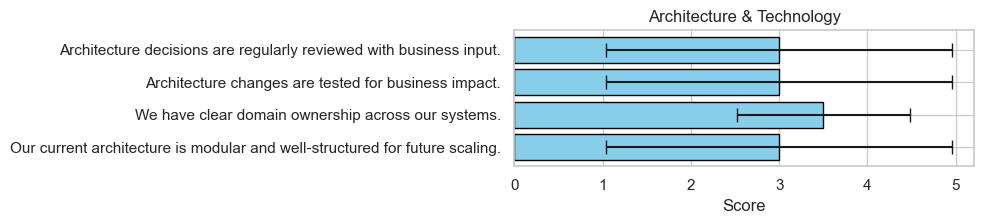

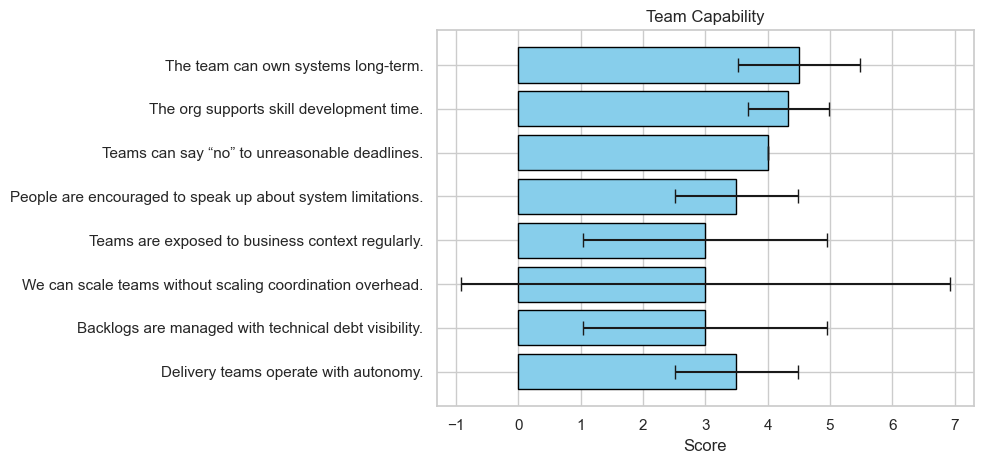

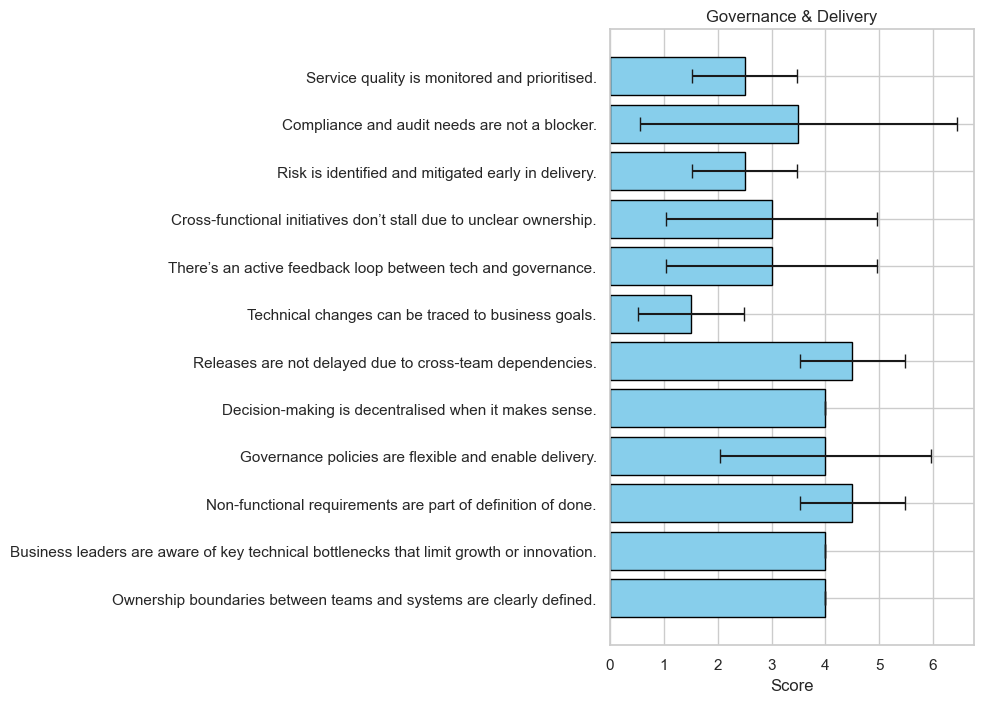

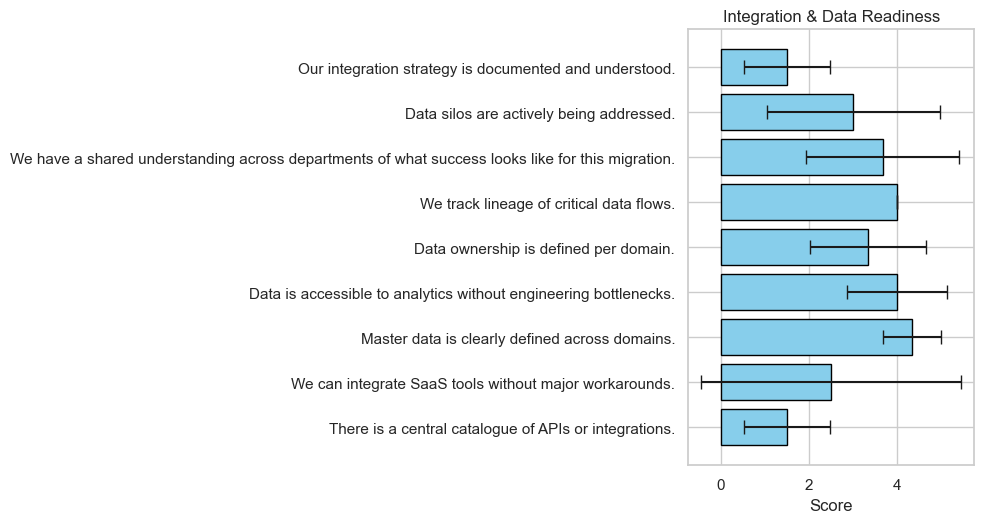

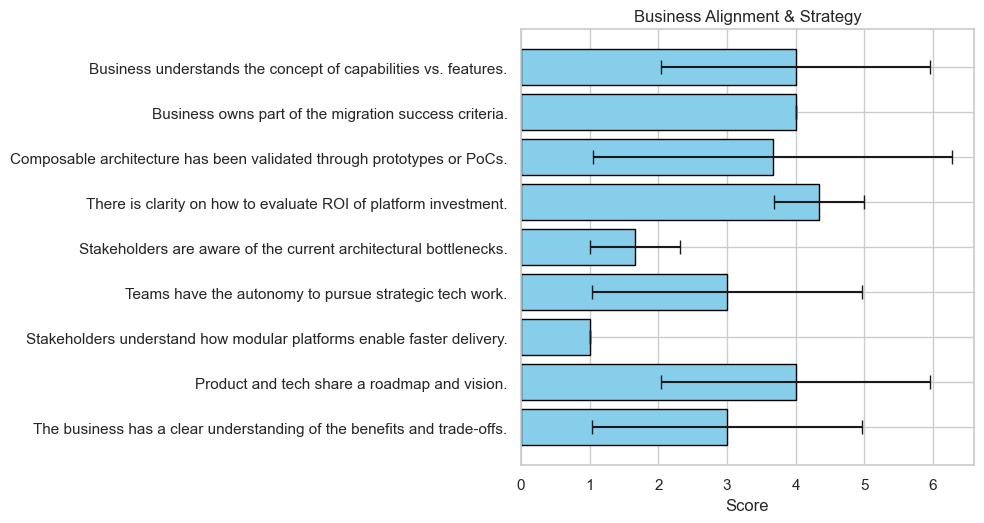

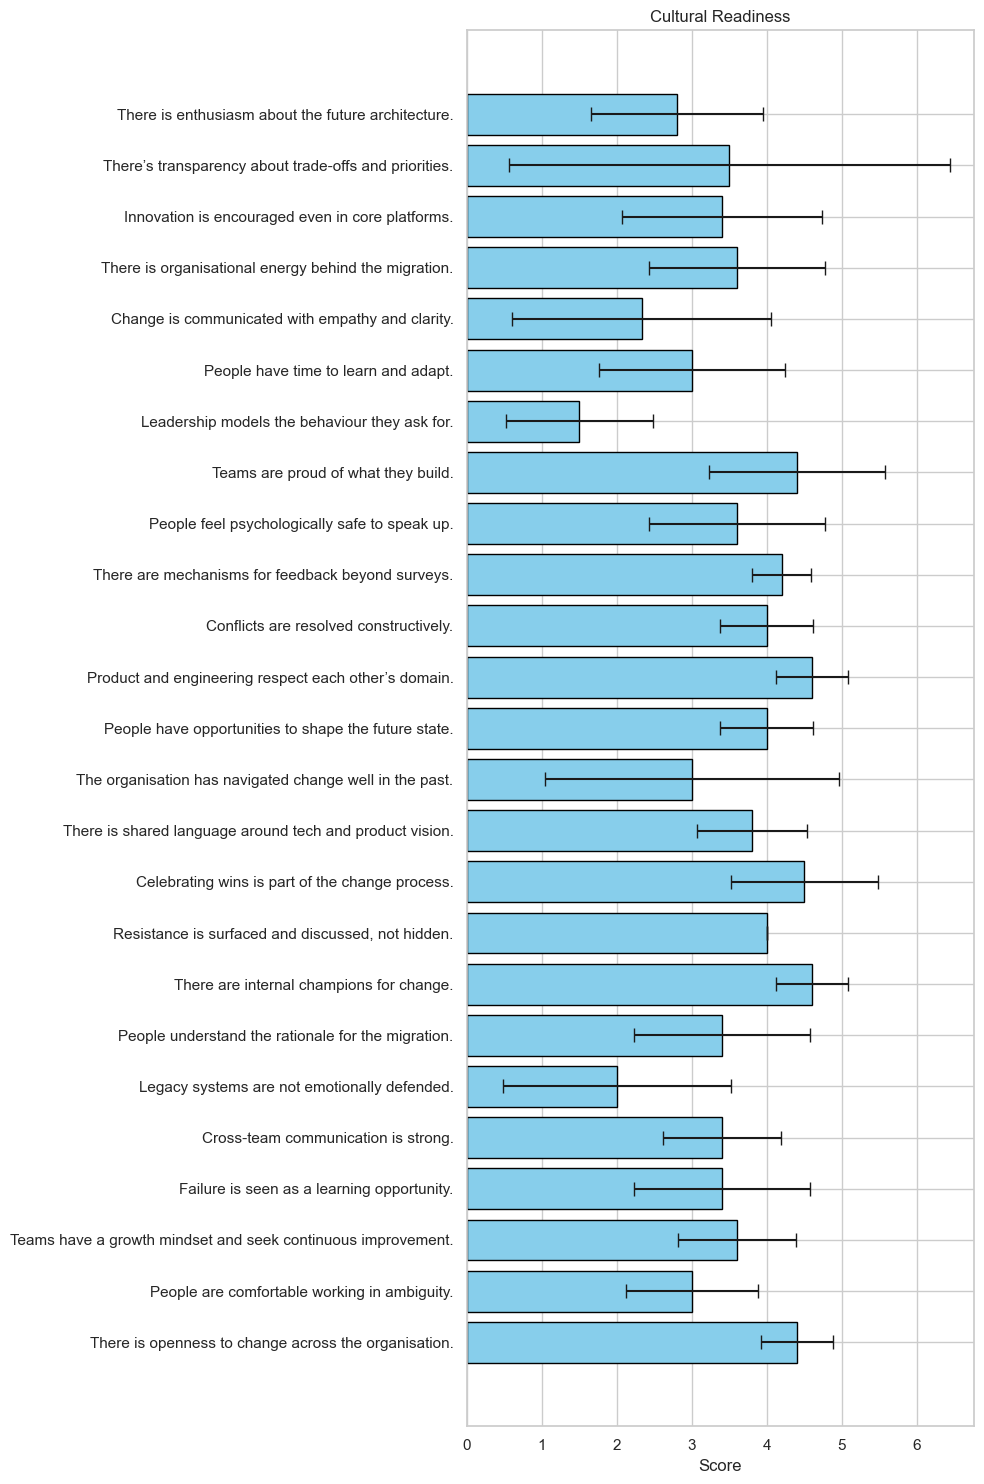

In [42]:
# Group questions by their domain
domains = questionnaire['Category'].unique()

# Iterate through each domain
for domain in domains:
    # Filter questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    valid_domain_question_ids = [qid for qid in domain_question_ids if qid in combined_quantitative_df.columns]
    
    # Filter the quantitative data for the current domain's questions
    domain_data = combined_quantitative_df[valid_domain_question_ids].replace(0, np.nan)
    
    # Map question IDs to their full text
    question_text_mapping = questionnaire['Question'].to_dict()
    domain_data.rename(columns=question_text_mapping, inplace=True)
    
    # Calculate confidence intervals for each question
    ci_data = []
    for question in domain_data.columns:
        scores = domain_data[question].dropna()
        if len(scores) > 1:  # Ensure there are enough data points
            mean = scores.mean()
            sem = scores.sem()  # Standard error of the mean
            ci = 1.96 * sem  # 95% confidence interval
            ci_data.append((question, mean - ci, mean + ci))
    
    # Extract question texts and their confidence intervals
    questions = [item[0] for item in ci_data]
    lower_bounds = [item[1] for item in ci_data]
    upper_bounds = [item[2] for item in ci_data]
    means = [(low + up) / 2 for low, up in zip(lower_bounds, upper_bounds)]
    errors = [(up - low) / 2 for low, up in zip(lower_bounds, upper_bounds)]
    
    # Create the plot
    plt.figure(figsize=(10, len(questions) * 0.6))
    plt.barh(questions, means, xerr=errors, color='skyblue', edgecolor='black', capsize=5)
    plt.xlabel("Score")
    plt.title(f"{domain}")
    plt.tight_layout()
    plt.show()

### Critical questions dragging scores down

In [43]:
# Filter for critical questions
critical_question_ids = questionnaire[questionnaire['Critical']].index

# Filter the quantitative data for critical questions
critical_data = combined_quantitative_df[critical_question_ids]

# Calculate the average score for each critical question excluding NaN and 0 values
critical_question_averages = critical_data[critical_data > 0].mean(axis=0)

# Identify critical questions with low average scores
low_scoring_critical_questions = critical_question_averages[critical_question_averages < threshold_confidence_low]

# Map question IDs to their text
low_scoring_critical_questions_text = questionnaire.loc[low_scoring_critical_questions.index, 'Question']
                                                        
# Print the results
print("Critical Questions Dragging Scores Down:")
for question_id, score in low_scoring_critical_questions.items():
    print(f"ID: {question_id}, Score: {score:.2f}, Question: {low_scoring_critical_questions_text[question_id]}")

Critical Questions Dragging Scores Down:
ID: 3, Score: 1.00, Question: Systems are loosely coupled and do not require synchronous coordination.
ID: 4, Score: 2.00, Question: Our platform supports composable integrations via well-defined APIs.
ID: 11, Score: 1.00, Question: Architecture evolution is tracked over time (e.g. ADRs, docs).
ID: 30, Score: 2.00, Question: Engineers can deploy without depending on other teams.
ID: 42, Score: 2.00, Question: Knowledge is not concentrated in a few individuals.
ID: 53, Score: 1.00, Question: Services can be deployed independently.
ID: 68, Score: 2.00, Question: There is clarity on the governance of shared components.
ID: 76, Score: 2.00, Question: Our systems use consistent API patterns.
ID: 77, Score: 2.00, Question: Integration points are documented and versioned.
ID: 79, Score: 2.00, Question: New services can be onboarded with minimal effort.
ID: 81, Score: 2.00, Question: Data schemas are governed and not duplicated across services.
ID: 88, 

### Non critical questions, which have low results

In [44]:

# Percentage of participants who had to answer for a question to be considered relevant
threshold_valid_percentage = 0.75

# Filter for non-critical questions
non_critical_question_ids = questionnaire[~questionnaire['Critical']].index

# Filter the quantitative data for non-critical questions
non_critical_data = combined_quantitative_df[non_critical_question_ids.intersection(combined_quantitative_df.columns)]

# Calculate the average score for each non-critical question excluding NaN and 0 values
non_critical_question_averages = non_critical_data[non_critical_data > 0].mean(axis=0)

# Identify non critical questions with low average scores
low_scoring_non_critical_questions = non_critical_question_averages[non_critical_question_averages < threshold_confidence_low]

# Validate if the question was answered by at least 60% of all participants
valid_question_ids = non_critical_data.columns[(non_critical_data > 0).sum() >= (len(non_critical_data) * threshold_valid_percentage)]
low_scoring_non_critical_questions = low_scoring_non_critical_questions[low_scoring_non_critical_questions.index.isin(valid_question_ids)]

# Map question IDs to their text
low_scoring_non_critical_questions_text = questionnaire.loc[low_scoring_non_critical_questions.index, 'Question']

# Print the results
print(f"Non-Critical Questions Dragging Scores Down (excluding questions answered by less than {threshold_valid_percentage * 100}% of participants):")
for question_id, score in low_scoring_non_critical_questions.items():
    print(f"ID: {question_id}, Score: {score:.2f}, Question: {low_scoring_non_critical_questions_text[question_id]}, Responses: {(non_critical_data[question_id] > 0).sum()}")

Non-Critical Questions Dragging Scores Down (excluding questions answered by less than 75.0% of participants):
ID: 150, Score: 2.80, Question: There is enthusiasm about the future architecture., Responses: 5
